In [1]:
%enable_monotone_updates

<div style='padding-left: 3em; font-size: 0.8em; background-color: #f0f0f8; margin-bottom: 0em;'><b>Cell a74f0803-86cf-408f-9650-cf31b7e605ac</b></div>

[18:46:59] [[monotone] Enabling monotone updates enforcement]
[18:46:59] [[monotone] Auto-enabling global tracking (required for RBW detection)]


<div style='padding-left: 3em; font-size: 0.8em; background-color: #f0f0f8; margin-bottom: 0em;'>📊 Global variable tracking enabled</div>

<div style='padding-left: 3em; font-size: 0.8em; background-color: #f0f0f8; margin-bottom: 0em;'>✅ Monotone updates enforcement enabled</div>

[18:46:59] [[monotone] Checking monotonicity for cell a74f0803-86cf-408f-9650-cf31b7e605ac...]
[18:46:59]   [[monotone] Read-before-write vars: set()]
[18:46:59]   [[monotone] No RBW vars to check, skipping]
[18:46:59] [0 ms]


This solution is largely based on [Konstantin Dmitriev's starter model](https://www.kaggle.com/code/kdmitrie/pg501-model-2-decomposition-country-doy-factor?scriptVersionId=220159752). I recommend reading through his notebook first as it provides wonderful explanations for many of the factors included below.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import datetime as dt
import holidays
from sklearn.linear_model import Ridge

<div style='padding-left: 3em; font-size: 0.8em; background-color: #f0f0f8; margin-bottom: 0em;'><b>Cell 84af</b></div>

[18:46:59] [[monotone] Saving pre-checkpoint for cell 84af...]
[18:46:59]   [Deep copying user namespace... 2 ms]
[18:46:59] [2 ms]


<div style='padding-left: 3em; font-size: 0.8em; background-color: #f0f0f8; margin-bottom: 0em;'><details style='display: inline-block; text-align: left;'><summary>🔍 2.69s</summary>

<pre style='margin: 0;'><code>                                                                                                                                                                                          Cell 84af: % of time = 100.00% (2.465s) out of 2.465s.                                                                                                                                                                                           
        ╷        ╷       ╷       ╷                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                             
        │Time    │–––––– │–––––– │                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                             
  Line  │Python  │native │system │Cell 84af                                                                                                                                                                                                                                                                                                                                                                                                
╺━━━━━━━┿━━━━━━━━┿━━━━━━━┿━━━━━━━┿━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╸
      1 │        │       │       │import numpy as np                                                                                                                                                                                                                                                                                                                                                                                                                                                                                           
      2 │        │       │       │import pandas as pd                                                                                                                                                                                                                                                                                                                                                                                                                                                                                          
      3 │    9%  │   21% │   4%  │import matplotlib.pyplot as plt                                                                                                                                                                                                                                                                                                                                                                                                                                                                              
      4 │        │       │       │import datetime as dt                                                                                                                                                                                                                                                                                                                                                                                                                                                                                        
      5 │        │       │       │import holidays                                                                                                                                                                                                                                                                                                                                                                                                                                                                                              
      6 │   18%  │   33% │  15%  │from sklearn.linear_model import Ridge                                                                                                                                                                                                                                                                                                                                                                                                                                                                       
        ╵        ╵       ╵       ╵                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                             
</code></pre>

</details></div>

[18:47:02] [[monotone] Checking monotonicity for cell 84af...]
[18:47:02]   [[monotone] Read-before-write vars: set()]
[18:47:02]   [[monotone] No RBW vars to check, skipping]
[18:47:02] [0 ms]


In [3]:
from scipy.optimize import minimize
from sklearn.linear_model import LinearRegression

def fit_mape_linear_model(X, y):
    # Ensure X is a 2D array
    X = np.asarray(X)
    y = np.asarray(y).squeeze()
    
    # Add bias term to X
    X = np.column_stack((np.ones(X.shape[0]), X))
    
    # Define the MAPE loss function
    def mape_loss(beta, X, y):
        y_pred = X @ beta
        return np.mean(np.abs((y - y_pred) / y)) * 100
    
    # Initial guess for parameters
    init_params = np.zeros(X.shape[1])
    
    # Minimize the MAPE loss
    result = minimize(mape_loss, init_params, args=(X, y), method='L-BFGS-B')
    
    # Extract optimized parameters
    beta_opt = result.x
    
    # Create and return an sklearn LinearRegression model
    model = LinearRegression()
    model.coef_ = beta_opt[1:]
    model.intercept_ = beta_opt[0]
    return model

<div style='padding-left: 3em; font-size: 0.8em; background-color: #f0f0f8; margin-bottom: 0em;'><b>Cell e523</b></div>

[18:47:02] [[monotone] Saving pre-checkpoint for cell e523...]
[18:47:02]   [Deep copying user namespace... 0 ms]
[18:47:02] [0 ms]


<div style='padding-left: 3em; font-size: 0.8em; background-color: #f0f0f8; margin-bottom: 0em;'>⏱️ 0.11s</div>

[18:47:02] [[monotone] Checking monotonicity for cell e523...]
[18:47:02]   [[monotone] Read-before-write vars: set()]
[18:47:02]   [[monotone] No RBW vars to check, skipping]
[18:47:02] [0 ms]


In [4]:
train = pd.read_csv('./train.csv', parse_dates=['date'])
test = pd.read_csv('./test.csv', parse_dates=['date'])
train = train.dropna().reset_index(drop=True)
df = pd.concat([train, test], sort=False).reset_index(drop=True)
df

<div style='padding-left: 3em; font-size: 0.8em; background-color: #f0f0f8; margin-bottom: 0em;'><b>Cell 725f</b></div>

[18:47:02] [[monotone] Saving pre-checkpoint for cell 725f...]
[18:47:02]   [Deep copying user namespace... 0 ms]
[18:47:02] [1 ms]
            id       date  ...             product num_sold
0            1 2010-01-01  ...              Kaggle    973.0
1            2 2010-01-01  ...        Kaggle Tiers    906.0
2            3 2010-01-01  ...            Kerneler    423.0
3            4 2010-01-01  ...  Kerneler Dark Mode    491.0
4            5 2010-01-01  ...   Holographic Goose    300.0
...        ...        ...  ...                 ...      ...
319804  328675 2019-12-31  ...   Holographic Goose      NaN
319805  328676 2019-12-31  ...              Kaggle      NaN
319806  328677 2019-12-31  ...        Kaggle Tiers      NaN
319807  328678 2019-12-31  ...            Kerneler      NaN
319808  328679 2019-12-31  ...  Kerneler Dark Mode      NaN

[319809 rows x 6 columns]


<div style='padding-left: 3em; font-size: 0.8em; background-color: #f0f0f8; margin-bottom: 0em;'><details style='display: inline-block; text-align: left;'><summary>🔍 1.27s</summary>

<pre style='margin: 0;'><code>                                                                                                                                                                                       Cell 725f: % of time = 100.00% (633.432ms) out of 633.432ms.                                                                                                                                                                                        
        ╷        ╷       ╷       ╷                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                             
        │Time    │–––––– │–––––– │                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                             
  Line  │Python  │native │system │Cell 725f                                                                                                                                                                                                                                                                                                                                                                                                
╺━━━━━━━┿━━━━━━━━┿━━━━━━━┿━━━━━━━┿━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╸
      1 │   10%  │   41% │  16%  │train = pd.read_csv('./train.csv', parse_dates=['date'])                                                                                                                                                                                                                                                                                                                                                                                                                                                     
      2 │    4%  │    4% │   3%  │test = pd.read_csv('./test.csv', parse_dates=['date'])                                                                                                                                                                                                                                                                                                                                                                                                                                                       
      3 │    3%  │    5% │   2%  │train = train.dropna().reset_index(drop=True)                                                                                                                                                                                                                                                                                                                                                                                                                                                                
      4 │        │    8% │   2%  │df = pd.concat([train, test], sort=False).reset_index(drop=True)                                                                                                                                                                                                                                                                                                                                                                                                                                             
      5 │        │       │       │__val = df                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                   
      6 │        │       │       │if __val is not None:                                                                                                                                                                                                                                                                                                                                                                                                                                                                                        
      7 │        │       │       │    print(repr(__val))                                                                                                                                                                                                                                                                                                                                                                                                                                                                                       
        ╵        ╵       ╵       ╵                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                             
</code></pre>

</details></div>

[18:47:03] [[monotone] Checking monotonicity for cell 725f...]
[18:47:03]   [[monotone] Read-before-write vars: set()]
[18:47:03]   [[monotone] No RBW vars to check, skipping]
[18:47:03] [0 ms]


##### Useful Columns

In [5]:
df['year'] = df['date'].dt.year
df['n_day'] = (df['date'] - df['date'].min()).dt.days
df['weekday'] = df['date'].dt.weekday
df['day_of_year'] = df['date'].dt.dayofyear

# Generate Wave Columns
wave_columns = []
# subtract leap dates
df.loc[df['date'] > dt.datetime(2012, 2, 29), 'n_day'] -= 1
df.loc[df['date'] > dt.datetime(2016, 2, 29), 'n_day'] -= 1

for i in range(1, 10):

    df[f'wave_sin{i}'] = np.sin(np.pi * i * df['n_day'] / 365)
    df[f'wave_cos{i}'] = np.cos(np.pi * i * df['n_day'] / 365)
    wave_columns.append(f'wave_sin{i}')
    wave_columns.append(f'wave_cos{i}')

<div style='padding-left: 3em; font-size: 0.8em; background-color: #f0f0f8; margin-bottom: 0em;'><b>Cell 87a8d391-3255-402e-9660-4aef6588460e</b></div>

[18:47:03] [[monotone] Saving pre-checkpoint for cell 87a8d391-3255-402e-9660-4aef6588460e...]
[18:47:04]   [Deep copying user namespace...]
[18:47:04]     [Converted column country from object to string]
[18:47:04]     [Converted column store from object to string]
[18:47:04]     [Converted column product from object to string]
[18:47:04]     [Deep copying variable train took 0.012 seconds]
[18:47:04]     [Converted column country from object to string]
[18:47:04]     [Converted column store from object to string]
[18:47:04]     [Converted column product from object to string]
[18:47:04]     [Converted column country from object to string]
[18:47:04]     [Converted column store from object to string]
[18:47:04]     [Converted column product from object to string]
[18:47:04]     [Deep copying variable df took 0.017 seconds]
[18:47:04]   [35 ms]
[18:47:04] [533 ms]


<div style='padding-left: 3em; font-size: 0.8em; background-color: #f0f0f8; margin-bottom: 0em;'><details style='display: inline-block; text-align: left;'><summary>🔍 0.52s</summary>

<pre style='margin: 0;'><code>                                                                                                                                                                                       Cell 87a8d391-3255-402e-9660-4aef6588460e: % of time = 100.00% (337.084ms) out of 337.084ms.                                                                                                                                                                                        
        ╷        ╷       ╷       ╷                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                             
        │Time    │–––––– │–––––– │                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                             
  Line  │Python  │native │system │Cell 87a8d391-3255-402e-9660-4aef6588460e                                                                                                                                                                                                                                                                                                                                                                                                
╺━━━━━━━┿━━━━━━━━┿━━━━━━━┿━━━━━━━┿━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╸
      1 │        │       │       │df['year'] = df['date'].dt.year                                                                                                                                                                                                                                                                                                                                                                                                                                                                              
      2 │        │   72% │   7%  │df['n_day'] = (df['date'] - df['date'].min()).dt.days                                                                                                                                                                                                                                                                                                                                                                                                                                                        
      3 │        │    6% │   1%  │df['weekday'] = df['date'].dt.weekday                                                                                                                                                                                                                                                                                                                                                                                                                                                                        
      4 │        │       │       │df['day_of_year'] = df['date'].dt.dayofyear                                                                                                                                                                                                                                                                                                                                                                                                                                                                  
      5 │        │       │       │                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                             
      6 │        │       │       │# Generate Wave Columns                                                                                                                                                                                                                                                                                                                                                                                                                                                                                      
      7 │        │       │       │wave_columns = []                                                                                                                                                                                                                                                                                                                                                                                                                                                                                            
      8 │        │       │       │# subtract leap dates                                                                                                                                                                                                                                                                                                                                                                                                                                                                                        
      9 │        │    1% │       │df.loc[df['date'] > dt.datetime(2012, 2, 29), 'n_day'] -= 1                                                                                                                                                                                                                                                                                                                                                                                                                                                  
     10 │        │       │       │df.loc[df['date'] > dt.datetime(2016, 2, 29), 'n_day'] -= 1                                                                                                                                                                                                                                                                                                                                                                                                                                                  
     11 │        │       │       │                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                             
     12 │        │       │       │for i in range(1, 10):                                                                                                                                                                                                                                                                                                                                                                                                                                                                                       
     13 │        │       │       │                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                             
     14 │    2%  │    3% │   1%  │    df[f'wave_sin{i}'] = np.sin(np.pi * i * df['n_day'] / 365)                                                                                                                                                                                                                                                                                                                                                                                                                                               
     15 │    1%  │    2% │       │    df[f'wave_cos{i}'] = np.cos(np.pi * i * df['n_day'] / 365)                                                                                                                                                                                                                                                                                                                                                                                                                                               
     16 │        │       │       │    wave_columns.append(f'wave_sin{i}')                                                                                                                                                                                                                                                                                                                                                                                                                                                                      
     17 │        │       │       │    wave_columns.append(f'wave_cos{i}')                                                                                                                                                                                                                                                                                                                                                                                                                                                                      
        ╵        ╵       ╵       ╵                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                             
</code></pre>

</details></div>

[18:47:04] [[monotone] Checking monotonicity for cell 87a8d391-3255-402e-9660-4aef6588460e...]
[18:47:04]   [[monotone] Read-before-write vars: {'df'}]
[18:47:04]   [[monotone] Computing diff... 1 ms]
[18:47:04]   [[monotone] Diff result: no differences]
[18:47:04]   [[monotone] PASSED]
[18:47:04] [1 ms]


In [6]:
# Near Holiday
df['near_holiday'] = 0
for country in df['country'].unique():
    days = [day for day in holidays.CountryHoliday(country, years=df['year'].unique())] 
    for day in days:
        df.loc[(df.country == country) & (df['date'].dt.date < day + dt.timedelta(days=10)) & (df['date'].dt.date > day - dt.timedelta(days=10)), 'near_holiday'] = 1

<div style='padding-left: 3em; font-size: 0.8em; background-color: #f0f0f8; margin-bottom: 0em;'><b>Cell 02fe</b></div>

[18:47:04] [[monotone] Saving pre-checkpoint for cell 02fe...]
[18:47:05]   [Deep copying user namespace... 9 ms]
[18:47:05] [503 ms]


<div style='padding-left: 3em; font-size: 0.8em; background-color: #f0f0f8; margin-bottom: 0em;'><details style='display: inline-block; text-align: left;'><summary>🔍 103.17s</summary>

<pre style='margin: 0;'><code>                                                                                                                                                                                      Cell 02fe: % of time = 100.00% (2m:43.001s) out of 2m:43.001s.                                                                                                                                                                                       
        ╷        ╷       ╷       ╷                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                             
        │Time    │–––––– │–––––– │                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                             
  Line  │Python  │native │system │Cell 02fe                                                                                                                                                                                                                                                                                                                                                                                                
╺━━━━━━━┿━━━━━━━━┿━━━━━━━┿━━━━━━━┿━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╸
      1 │        │       │       │# Near Holiday                                                                                                                                                                                                                                                                                                                                                                                                                                                                                               
      2 │        │       │       │df['near_holiday'] = 0                                                                                                                                                                                                                                                                                                                                                                                                                                                                                       
      3 │        │       │       │for country in df['country'].unique():                                                                                                                                                                                                                                                                                                                                                                                                                                                                       
      4 │        │       │       │    days = [day for day in holidays.CountryHoliday(country, years=df['year'].unique())]                                                                                                                                                                                                                                                                                                                                                                                                                      
      5 │        │       │       │    for day in days:                                                                                                                                                                                                                                                                                                                                                                                                                                                                                         
      6 │   32%  │   61% │   6%  │        df.loc[(df.country == country) & (df['date'].dt.date < day + dt.timedelta(days=10)) & (df['date'].dt.date > day - dt.timedelta(days=10)), 'near_holiday'] = 1                                                                                                                                                                                                                                                                                                                                        
        ╵        ╵       ╵       ╵                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                             
</code></pre>

</details></div>

[18:48:48] [[monotone] Checking monotonicity for cell 02fe...]
[18:48:48]   [[monotone] Read-before-write vars: {'df'}]
[18:48:48]   [[monotone] Computing diff... 7 ms]
[18:48:48]   [[monotone] Diff result: no differences]
[18:48:48]   [[monotone] PASSED]
[18:48:48] [8 ms]


In [7]:
### Decomposition

<div style='padding-left: 3em; font-size: 0.8em; background-color: #f0f0f8; margin-bottom: 0em;'><b>Cell 6371a060-2818-4605-97af-10fe67b1451b</b></div>

[18:48:48] [[monotone] Saving pre-checkpoint for cell 6371a060-2818-4605-97af-10fe67b1451b...]
[18:48:48]   [Deep copying user namespace... 3 ms]
[18:48:48] [446 ms]


<div style='padding-left: 3em; font-size: 0.8em; background-color: #f0f0f8; margin-bottom: 0em;'>⏱️ 0.16s</div>

[18:48:48] [[monotone] Checking monotonicity for cell 6371a060-2818-4605-97af-10fe67b1451b...]
[18:48:48]   [[monotone] Read-before-write vars: set()]
[18:48:48]   [[monotone] No RBW vars to check, skipping]
[18:48:48] [0 ms]


##### GDP Factor

In [8]:
z = [year for year in df['year'].unique() for country in df['country'].unique()]

<div style='padding-left: 3em; font-size: 0.8em; background-color: #f0f0f8; margin-bottom: 0em;'><b>Cell f857cb90</b></div>

[18:48:48] [[monotone] Saving pre-checkpoint for cell f857cb90...]
[18:48:49]   [Deep copying user namespace... 3 ms]
[18:48:49] [434 ms]


<div style='padding-left: 3em; font-size: 0.8em; background-color: #f0f0f8; margin-bottom: 0em;'><details style='display: inline-block; text-align: left;'><summary>🔍 0.35s</summary>

<pre style='margin: 0;'><code>                                                                                                                                                                                       Cell f857cb90: % of time = 100.00% (196.975ms) out of 196.975ms.                                                                                                                                                                                        
        ╷        ╷       ╷       ╷                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                             
        │Time    │–––––– │–––––– │                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                             
  Line  │Python  │native │system │Cell f857cb90                                                                                                                                                                                                                                                                                                                                                                                                
╺━━━━━━━┿━━━━━━━━┿━━━━━━━┿━━━━━━━┿━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╸
      1 │    4%  │   85% │  11%  │z = [year for year in df['year'].unique() for country in df['country'].unique()]                                                                                                                                                                                                                                                                                                                                                                                                                             
        ╵        ╵       ╵       ╵                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                             
</code></pre>

</details></div>

[18:48:49] [[monotone] Checking monotonicity for cell f857cb90...]
[18:48:49]   [[monotone] Read-before-write vars: {'df'}]
[18:48:49]   [[monotone] Computing diff... 6 ms]
[18:48:49]   [[monotone] Diff result: no differences]
[18:48:49]   [[monotone] PASSED]
[18:48:49] [6 ms]


In [9]:

# import requests
# def get_gdp_per_capita(country,year):
#     while True:
#         try:
#             alpha3 = {'Canada': 'CAN', 'Finland': 'FIN',
#                       'Italy': 'ITA', 'Kenya': 'KEN', 
#                       'Norway': 'NOR', 'Singapore': 'SGP'}
#             url="https://api.worldbank.org/v2/country/{0}/indicator/NY.GDP.PCAP.CD?date={1}&format=json".format(alpha3[country],year)
#             print(url)
#             response = requests.get(url).json()
#             return response[1][0]['value']
#         except:
#             pass

# gdp = np.array([[get_gdp_per_capita(country, year) for year in df['year'].unique()] for country in df['country'].unique()])
# gdp_df = pd.DataFrame(gdp, columns=df['year'].unique(), index=df['country'].unique())

gdp_df = pd.read_json("gdp-cached.json")

for year in df['year'].unique():
    for country in df['country'].unique():
        df.loc[(df['year'] == year) & (df['country'] == country), 'gdp'] = gdp_df.loc[country, year]

<div style='padding-left: 3em; font-size: 0.8em; background-color: #f0f0f8; margin-bottom: 0em;'><b>Cell eb71</b></div>

[18:48:49] [[monotone] Saving pre-checkpoint for cell eb71...]
[18:48:50]   [Deep copying user namespace... 3 ms]
[18:48:50] [421 ms]


<div style='padding-left: 3em; font-size: 0.8em; background-color: #f0f0f8; margin-bottom: 0em;'><details style='display: inline-block; text-align: left;'><summary>🔍 1.55s</summary>

<pre style='margin: 0;'><code>                                                                                                                                                                                          Cell eb71: % of time = 100.00% (1.383s) out of 1.383s.                                                                                                                                                                                           
        ╷        ╷       ╷       ╷                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                             
        │Time    │–––––– │–––––– │                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                             
  Line  │Python  │native │system │Cell eb71                                                                                                                                                                                                                                                                                                                                                                                                
╺━━━━━━━┿━━━━━━━━┿━━━━━━━┿━━━━━━━┿━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╸
      1 │        │       │       │                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                             
      2 │        │       │       │# import requests                                                                                                                                                                                                                                                                                                                                                                                                                                                                                            
      3 │        │       │       │# def get_gdp_per_capita(country,year):                                                                                                                                                                                                                                                                                                                                                                                                                                                                      
      4 │        │       │       │#     while True:                                                                                                                                                                                                                                                                                                                                                                                                                                                                                            
      5 │        │       │       │#         try:                                                                                                                                                                                                                                                                                                                                                                                                                                                                                               
      6 │        │       │       │#             alpha3 = {'Canada': 'CAN', 'Finland': 'FIN',                                                                                                                                                                                                                                                                                                                                                                                                                                                   
      7 │        │       │       │#                       'Italy': 'ITA', 'Kenya': 'KEN',                                                                                                                                                                                                                                                                                                                                                                                                                                                      
      8 │        │       │       │#                       'Norway': 'NOR', 'Singapore': 'SGP'}                                                                                                                                                                                                                                                                                                                                                                                                                                                 
      9 │        │       │       │#             url="https://api.worldbank.org/v2/country/{0}/indicator/NY.GDP.PCAP.CD?date={1}&format=json".format(alpha3[country],year)                                                                                                                                                                                                                                                                                                                                                                      
     10 │        │       │       │#             print(url)                                                                                                                                                                                                                                                                                                                                                                                                                                                                                     
     11 │        │       │       │#             response = requests.get(url).json()                                                                                                                                                                                                                                                                                                                                                                                                                                                            
     12 │        │       │       │#             return response[1][0]['value']                                                                                                                                                                                                                                                                                                                                                                                                                                                                 
     13 │        │       │       │#         except:                                                                                                                                                                                                                                                                                                                                                                                                                                                                                            
     14 │        │       │       │#             pass                                                                                                                                                                                                                                                                                                                                                                                                                                                                                           
     15 │        │       │       │                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                             
     16 │        │       │       │# gdp = np.array([[get_gdp_per_capita(country, year) for year in df['year'].unique()] for country in df['country'].unique()])                                                                                                                                                                                                                                                                                                                                                                                
     17 │        │       │       │# gdp_df = pd.DataFrame(gdp, columns=df['year'].unique(), index=df['country'].unique())                                                                                                                                                                                                                                                                                                                                                                                                                      
     18 │        │       │       │                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                             
     19 │        │       │       │gdp_df = pd.read_json("gdp-cached.json")                                                                                                                                                                                                                                                                                                                                                                                                                                                                     
     20 │        │       │       │                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                             
     21 │        │       │       │for year in df['year'].unique():                                                                                                                                                                                                                                                                                                                                                                                                                                                                             
     22 │    5%  │   30% │   3%  │    for country in df['country'].unique():                                                                                                                                                                                                                                                                                                                                                                                                                                                                   
     23 │   30%  │   27% │   5%  │        df.loc[(df['year'] == year) & (df['country'] == country), 'gdp'] = gdp_df.loc[country, year]                                                                                                                                                                                                                                                                                                                                                                                                         
        ╵        ╵       ╵       ╵                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                             
</code></pre>

</details></div>

[18:48:51] [[monotone] Checking monotonicity for cell eb71...]
[18:48:51]   [[monotone] Read-before-write vars: {'df'}]
[18:48:51]   [[monotone] Computing diff... 7 ms]
[18:48:51]   [[monotone] Diff result: no differences]
[18:48:51]   [[monotone] PASSED]
[18:48:51] [7 ms]


From broccoli beef's [discussion post comment](https://www.kaggle.com/competitions/playground-series-s5e1/discussion/555500#3091632). Using the following least MAPE linear fit improves predictions for kenya.

In [10]:
df['gdp_factor'] =  (-17643.346899+85.42355636*df['gdp']) / 365

<div style='padding-left: 3em; font-size: 0.8em; background-color: #f0f0f8; margin-bottom: 0em;'><b>Cell 9e69</b></div>

[18:48:51] [[monotone] Saving pre-checkpoint for cell 9e69...]
[18:48:52]   [Deep copying user namespace... 3 ms]
[18:48:52] [528 ms]


<div style='padding-left: 3em; font-size: 0.8em; background-color: #f0f0f8; margin-bottom: 0em;'>⏱️ 0.15s</div>

[18:48:52] [[monotone] Checking monotonicity for cell 9e69...]
[18:48:52]   [[monotone] Read-before-write vars: {'df'}]
[18:48:52]   [[monotone] Computing diff... 6 ms]
[18:48:52]   [[monotone] Diff result: no differences]
[18:48:52]   [[monotone] PASSED]
[18:48:52] [6 ms]


<div style='padding-left: 3em; font-size: 0.8em; background-color: #f0f0f8; margin-bottom: 0em;'><b>Cell 607c</b></div>

[18:48:52] [[monotone] Saving pre-checkpoint for cell 607c...]
[18:48:52]   [Deep copying user namespace... 4 ms]
[18:48:52] [442 ms]


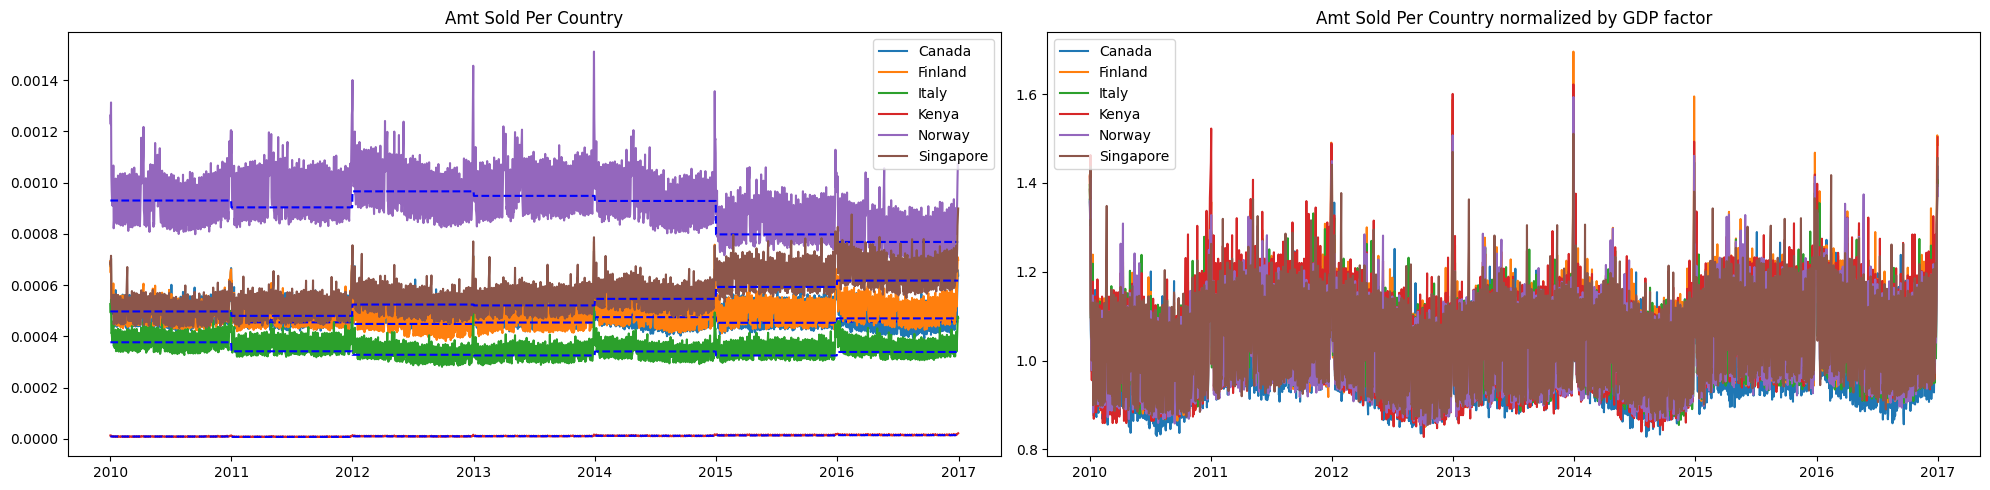

<div style='padding-left: 3em; font-size: 0.8em; background-color: #f0f0f8; margin-bottom: 0em;'>⚠️ The following objects cannot be passed between cells: fig, axs</div>

<div style='padding-left: 3em; font-size: 0.8em; background-color: #f0f0f8; margin-bottom: 0em;'><details style='display: inline-block; text-align: left;'><summary>🔍 5.76s</summary>

<pre style='margin: 0;'><code>                                                                                                                                                                                          Cell 607c: % of time = 100.00% (5.583s) out of 5.583s.                                                                                                                                                                                          
        ╷        ╷       ╷       ╷                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                             
        │Time    │–––––– │–––––– │                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                             
  Line  │Python  │native │system │Cell 607c                                                                                                                                                                                                                                                                                                                                                                                               
╺━━━━━━━┿━━━━━━━━┿━━━━━━━┿━━━━━━━┿━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╸
      1 │        │   21% │   4%  │fig, axs = plt.subplots(1, 2, figsize=(20, 5))                                                                                                                                                                                                                                                                                                                                                                                                                                                               
      2 │        │    4% │   1%  │grouped_data = df.groupby(['date', 'year', 'country'])['num_sold'].sum().reset_index()                                                                                                                                                                                                                                                                                                                                                                                                                       
      3 │        │       │       │total_per_day = df.groupby('year')['num_sold'].sum().reset_index()                                                                                                                                                                                                                                                                                                                                                                                                                                           
      4 │        │       │       │grouped_data = grouped_data.merge(total_per_day, on=['year'], suffixes=['', '_total']).reset_index()                                                                                                                                                                                                                                                                                                                                                                                                         
      5 │        │    3% │       │grouped_data = grouped_data.merge(df[['date', 'country', 'gdp_factor']], on=['date', 'country'])                                                                                                                                                                                                                                                                                                                                                                                                             
      6 │        │       │       │for country in df['country'].unique():                                                                                                                                                                                                                                                                                                                                                                                                                                                                       
      7 │    1%  │    5% │       │    country_data = grouped_data[(grouped_data['country'] == country) & (grouped_data['date'] < dt.datetime(2017, 1, 1))]                                                                                                                                                                                                                                                                                                                                                                                     
      8 │        │       │       │    axs[0].plot(country_data['date'], country_data['num_sold'] / country_data['num_sold_total'], '-', label=country)                                                                                                                                                                                                                                                                                                                                                                                         
      9 │        │       │       │    axs[0].plot(country_data['date'], country_data['gdp_factor'] / country_data['num_sold_total'], 'b--')                                                                                                                                                                                                                                                                                                                                                                                                    
     10 │        │       │       │axs[0].set_title('Amt Sold Per Country')                                                                                                                                                                                                                                                                                                                                                                                                                                                                     
     11 │        │       │       │axs[0].legend()                                                                                                                                                                                                                                                                                                                                                                                                                                                                                              
     12 │        │    1% │       │for country in df['country'].unique():                                                                                                                                                                                                                                                                                                                                                                                                                                                                       
     13 │        │    1% │       │    country_data = grouped_data[(grouped_data['country'] == country) & (grouped_data['date'] < dt.datetime(2017, 1, 1))]                                                                                                                                                                                                                                                                                                                                                                                     
     14 │        │       │       │    axs[1].plot(country_data['date'], country_data['num_sold'] / country_data['gdp_factor'], '-', label=country)                                                                                                                                                                                                                                                                                                                                                                                             
     15 │        │       │       │axs[1].set_title('Amt Sold Per Country normalized by GDP factor')                                                                                                                                                                                                                                                                                                                                                                                                                                            
     16 │        │       │       │axs[1].legend()                                                                                                                                                                                                                                                                                                                                                                                                                                                                                              
     17 │        │       │       │df['ratio'] = df['gdp_factor']                                                                                                                                                                                                                                                                                                                                                                                                                                                                               
     18 │        │       │       │df['total'] = df['num_sold'] / df['ratio']                                                                                                                                                                                                                                                                                                                                                                                                                                                                   
     19 │    4%  │   11% │   1%  │plt.tight_layout()                                                                                                                                                                                                                                                                                                                                                                                                                                                                                           
     20 │   19%  │   17% │   1%  │__val = plt.show()                                                                                                                                                                                                                                                                                                                                                                                                                                                                                           
     21 │        │       │       │if __val is not None:                                                                                                                                                                                                                                                                                                                                                                                                                                                                                        
     22 │        │       │       │    print(repr(__val))                                                                                                                                                                                                                                                                                                                                                                                                                                                                                       
        ╵        ╵       ╵       ╵                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                             
</code></pre>

</details></div>

[18:48:58] [[monotone] Checking monotonicity for cell 607c...]
[18:48:58]   [[monotone] Read-before-write vars: {'df'}]
[18:48:58]   [[monotone] Computing diff... 15 ms]
[18:48:58]   [[monotone] Diff result: no differences]
[18:48:58]   [[monotone] PASSED]
[18:48:58] [16 ms]


In [11]:
fig, axs = plt.subplots(1, 2, figsize=(20, 5))
grouped_data = df.groupby(['date', 'year', 'country'])['num_sold'].sum().reset_index()
total_per_day = df.groupby('year')['num_sold'].sum().reset_index()
grouped_data = grouped_data.merge(total_per_day, on=['year'], suffixes=['', '_total']).reset_index()
grouped_data = grouped_data.merge(df[['date', 'country', 'gdp_factor']], on=['date', 'country'])

for country in df['country'].unique():
    country_data = grouped_data[((grouped_data['country'] == country) & (grouped_data['date'] < dt.datetime(2017, 1, 1)))]
    axs[0].plot(country_data['date'], country_data['num_sold'] / country_data['num_sold_total'], '-', label=country)
    axs[0].plot(country_data['date'], country_data['gdp_factor'] / country_data['num_sold_total'], 'b--')
axs[0].set_title('Amt Sold Per Country')
axs[0].legend()

for country in df['country'].unique():
    country_data = grouped_data[((grouped_data['country'] == country) & (grouped_data['date'] < dt.datetime(2017, 1, 1)))]
    axs[1].plot(country_data['date'], country_data['num_sold'] / country_data['gdp_factor'], '-', label=country)
axs[1].set_title('Amt Sold Per Country normalized by GDP factor')
axs[1].legend()

df['ratio'] = df['gdp_factor']
df['total'] = df['num_sold'] / df['ratio']

plt.tight_layout()
plt.show()

##### Store Factor

<div style='padding-left: 3em; font-size: 0.8em; background-color: #f0f0f8; margin-bottom: 0em;'><b>Cell 777d</b></div>

[18:48:58] [[monotone] Saving pre-checkpoint for cell 777d...]
[18:48:59]   [Deep copying user namespace... 4 ms]
[18:48:59] [511 ms]
Store factor sum is 1.0


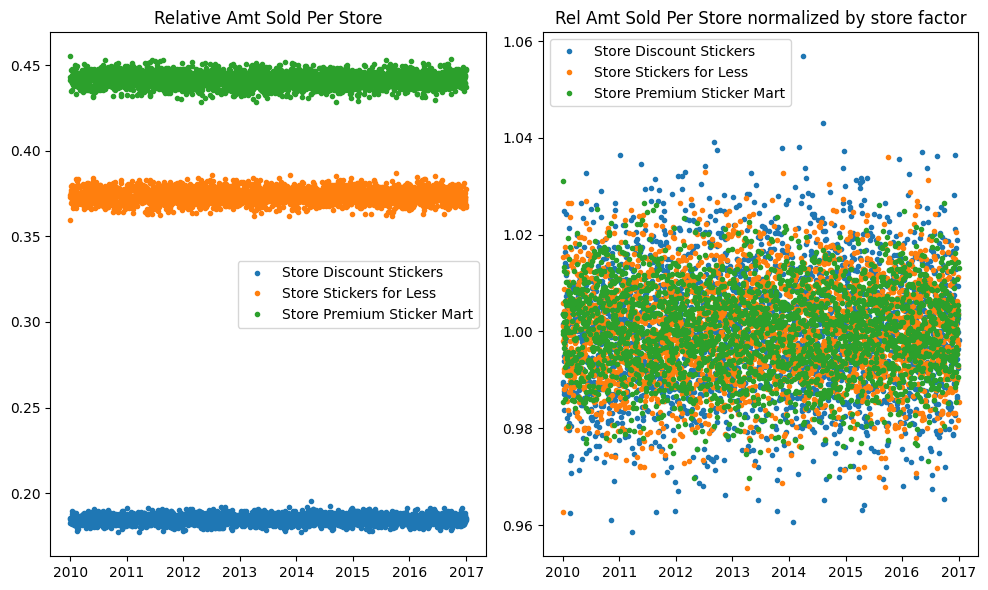

<div style='padding-left: 3em; font-size: 0.8em; background-color: #f0f0f8; margin-bottom: 0em;'>⚠️ The following objects cannot be passed between cells: fig, axs</div>

<div style='padding-left: 3em; font-size: 0.8em; background-color: #f0f0f8; margin-bottom: 0em;'><details style='display: inline-block; text-align: left;'><summary>🔍 1.42s</summary>

<pre style='margin: 0;'><code>                                                                                                                                                                                          Cell 777d: % of time = 100.00% (1.232s) out of 1.232s.                                                                                                                                                                                          
        ╷        ╷       ╷       ╷                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                             
        │Time    │–––––– │–––––– │                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                             
  Line  │Python  │native │system │Cell 777d                                                                                                                                                                                                                                                                                                                                                                                               
╺━━━━━━━┿━━━━━━━━┿━━━━━━━┿━━━━━━━┿━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╸
      1 │    2%  │   39% │   8%  │df_no_can_ken = df[~df['country'].isin(['Canada', 'Kenya'])]                                                                                                                                                                                                                                                                                                                                                                                                                                                 
      2 │        │       │       │fig, axs = plt.subplots(1, 2, figsize=(10, 6))                                                                                                                                                                                                                                                                                                                                                                                                                                                               
      3 │    1%  │    5% │   2%  │store_data = df_no_can_ken.groupby(['date', 'store'])['num_sold'].sum().reset_index()                                                                                                                                                                                                                                                                                                                                                                                                                        
      4 │        │       │       │total_per_day = df_no_can_ken.groupby('date')['num_sold'].sum().reset_index()                                                                                                                                                                                                                                                                                                                                                                                                                                
      5 │        │       │       │store_data = store_data.merge(total_per_day, on=['date'], suffixes=['', '_total'])                                                                                                                                                                                                                                                                                                                                                                                                                           
      6 │        │       │       │store_data['store_factor'] = store_data['num_sold'] / store_data['num_sold_total']                                                                                                                                                                                                                                                                                                                                                                                                                           
      7 │        │       │       │store_df = store_data.groupby('store')['store_factor'].mean().reset_index()                                                                                                                                                                                                                                                                                                                                                                                                                                  
      8 │        │       │       │store_data.drop('store_factor', axis=1, inplace=True)                                                                                                                                                                                                                                                                                                                                                                                                                                                        
      9 │        │       │       │store_data = store_data.merge(store_df, on=['store'])                                                                                                                                                                                                                                                                                                                                                                                                                                                        
     10 │        │    1% │       │print(f"Store factor sum is {store_df['store_factor'].sum()}")                                                                                                                                                                                                                                                                                                                                                                                                                                               
     11 │        │       │       │df = df.drop('store_factor', axis=1, errors='ignore')                                                                                                                                                                                                                                                                                                                                                                                                                                                        
     12 │        │    2% │       │df = df.merge(store_df, on=['store'])                                                                                                                                                                                                                                                                                                                                                                                                                                                                        
     13 │        │       │       │df['ratio'] = df['store_factor']                                                                                                                                                                                                                                                                                                                                                                                                                                                                             
     14 │        │       │       │for store in df['store'].unique():                                                                                                                                                                                                                                                                                                                                                                                                                                                                           
     15 │        │       │       │    data = store_data[store_data['store'] == store]                                                                                                                                                                                                                                                                                                                                                                                                                                                          
     16 │        │       │       │    axs[0].plot(data['date'], data['num_sold'] / data['num_sold_total'], '.', label=f'Store {store}')                                                                                                                                                                                                                                                                                                                                                                                                        
     17 │        │       │       │axs[0].set_title('Relative Amt Sold Per Store')                                                                                                                                                                                                                                                                                                                                                                                                                                                              
     18 │        │       │       │axs[0].legend()                                                                                                                                                                                                                                                                                                                                                                                                                                                                                              
     19 │        │       │       │for store in df['store'].unique():                                                                                                                                                                                                                                                                                                                                                                                                                                                                           
     20 │        │       │       │    data = store_data[store_data['store'] == store]                                                                                                                                                                                                                                                                                                                                                                                                                                                          
     21 │        │       │       │    axs[1].plot(data['date'], data['num_sold'] / data['num_sold_total'] / data['store_factor'], '.', label=f'Store {store}')                                                                                                                                                                                                                                                                                                                                                                                 
     22 │        │       │       │axs[1].set_title('Rel Amt Sold Per Store normalized by store factor')                                                                                                                                                                                                                                                                                                                                                                                                                                        
     23 │        │       │       │axs[1].legend()                                                                                                                                                                                                                                                                                                                                                                                                                                                                                              
     24 │    3%  │    9% │   2%  │plt.tight_layout()                                                                                                                                                                                                                                                                                                                                                                                                                                                                                           
     25 │    8%  │   11% │   1%  │__val = plt.show()                                                                                                                                                                                                                                                                                                                                                                                                                                                                                           
     26 │        │       │       │if __val is not None:                                                                                                                                                                                                                                                                                                                                                                                                                                                                                        
     27 │        │       │       │    print(repr(__val))                                                                                                                                                                                                                                                                                                                                                                                                                                                                                       
        ╵        ╵       ╵       ╵                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                             
</code></pre>

</details></div>

[18:49:00] [[monotone] Checking monotonicity for cell 777d...]
[18:49:00]   [[monotone] Read-before-write vars: {'df'}]
[18:49:00]   [[monotone] Computing diff... 5 ms]
[18:49:00]   [[monotone] Diff result: no differences]
[18:49:00]   [[monotone] PASSED]
[18:49:00] [5 ms]


In [12]:
df_no_can_ken = df[~df['country'].isin(['Canada', 'Kenya'])]

fig, axs = plt.subplots(1, 2, figsize=(10, 6))
store_data = df_no_can_ken.groupby(['date', 'store'])['num_sold'].sum().reset_index()
total_per_day = df_no_can_ken.groupby('date')['num_sold'].sum().reset_index()
store_data = store_data.merge(total_per_day, on=['date'], suffixes=['', '_total'])

# Calculate store factor
store_data['store_factor'] = store_data['num_sold'] / store_data['num_sold_total']
store_df = store_data.groupby('store')['store_factor'].mean().reset_index()
store_data.drop('store_factor', axis=1, inplace=True)
store_data = store_data.merge(store_df, on=['store'])
print(f"Store factor sum is {store_df['store_factor'].sum()}")

# Merge store factor into df
df = df.drop('store_factor', axis=1, errors='ignore')
df = df.merge(store_df, on=['store'])
df['ratio'] = df['store_factor']

for store in df['store'].unique():
    data = store_data[store_data['store'] == store]
    axs[0].plot(data['date'], data['num_sold'] / data['num_sold_total'], '.', label=f'Store {store}')
axs[0].set_title('Relative Amt Sold Per Store')
axs[0].legend()

# Normalize by current ratio
for store in df['store'].unique():
    data = store_data[store_data['store'] == store]
    axs[1].plot(data['date'], data['num_sold'] /  data['num_sold_total'] /  data['store_factor'], '.', label=f'Store {store}')
axs[1].set_title('Rel Amt Sold Per Store normalized by store factor') 
axs[1].legend()

plt.tight_layout()
plt.show()

##### Product Factor

In [13]:
df['ratio'] = df['store_factor'] * df['gdp_factor']
df['total'] = df['num_sold'] / df['ratio']

df_no_can_ken = df[~df['country'].isin(['Canada', 'Kenya'])]
total_per_day = df_no_can_ken.groupby('date')['total'].sum().reset_index()
df_no_can_ken = df_no_can_ken.merge(total_per_day, on=['date'], suffixes=['', '_per_day'])
df_no_can_ken['total_perc_per_day'] = df_no_can_ken['total'] / df_no_can_ken['total_per_day'] 
fig, axs = plt.subplots(1, 2, figsize=(20, 5))

# fit wave columns to each product
df['product_factor'] = None
for product in df['product'].unique():

    df_product = df_no_can_ken[((df_no_can_ken['product'] == product) & (df_no_can_ken['date'] < dt.datetime(2017, 1, 1)))].groupby('date')
    X = df_product[wave_columns].mean()
    y = df_product['total_perc_per_day'].sum()
    
    model = fit_mape_linear_model(X, y)
    df.loc[df['product'] == product, 'product_factor'] = model.predict(df[df['product'] == product][wave_columns])

    axs[0].plot(df_product['date'].unique().index, y, '-', label=product)
    axs[0].plot(df_product['date'].unique().index, model.predict(X), 'b--')
axs[0].set_title('Amt Sold Per Product')
axs[0].legend()

# Visualize the result
df_no_can_ken = df[~df['country'].isin(['Canada', 'Kenya'])]
total_per_day = df_no_can_ken.groupby('date')['total'].sum().reset_index()
df_no_can_ken = df_no_can_ken.merge(total_per_day, on=['date'], suffixes=['', '_per_day'])
df_no_can_ken['total_perc_per_day'] = df_no_can_ken['total'] / df_no_can_ken['total_per_day'] 
for product in df['product'].unique():
    df_product = df_no_can_ken[((df_no_can_ken['product'] == product) & (df_no_can_ken['date'] < dt.datetime(2017, 1, 1)))].groupby('date')
    y = df_product['total_perc_per_day'].sum()
    product_factor = df_product['product_factor'].mean()
    axs[1].plot(df_product['date'].unique().index, y / product_factor, '-', label=product)
axs[1].set_title('Amt Sold Per Product normalized by Product factor')
axs[1].legend()

df['ratio'] = df['store_factor'] * df['gdp_factor'] * df['product_factor']
df['total'] = df['num_sold'] / df['ratio']

<div style='padding-left: 3em; font-size: 0.8em; background-color: #f0f0f8; margin-bottom: 0em;'><b>Cell feeb</b></div>

[18:49:00] [[monotone] Saving pre-checkpoint for cell feeb...]
[18:49:01]   [Deep copying user namespace... 7 ms]
[18:49:01] [726 ms]


/Users/freund/miniconda3/envs/ferret/lib/python3.11/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(
/Users/freund/miniconda3/envs/ferret/lib/python3.11/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(
/Users/freund/miniconda3/envs/ferret/lib/python3.11/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(
/Users/freund/miniconda3/envs/ferret/lib/python3.11/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(
/Users/freund/miniconda3/envs/ferret/lib/python3.11/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but LinearRegression was fitted without featur

<div style='padding-left: 3em; font-size: 0.8em; background-color: #f0f0f8; margin-bottom: 0em;'>⚠️ The following objects cannot be passed between cells: fig, axs</div>

<div style='padding-left: 3em; font-size: 0.8em; background-color: #f0f0f8; margin-bottom: 0em;'><details style='display: inline-block; text-align: left;'><summary>🔍 6.73s</summary>

<pre style='margin: 0;'><code>                                                                                                                                                                                          Cell feeb: % of time =  79.76% (4.952s) out of 6.209s.                                                                                                                                                                                          
        ╷        ╷       ╷       ╷                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                             
        │Time    │–––––– │–––––– │                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                             
  Line  │Python  │native │system │Cell feeb                                                                                                                                                                                                                                                                                                                                                                                               
╺━━━━━━━┿━━━━━━━━┿━━━━━━━┿━━━━━━━┿━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╸
      1 │        │       │       │df['ratio'] = df['store_factor'] * df['gdp_factor']                                                                                                                                                                                                                                                                                                                                                                                                                                                          
      2 │        │       │       │df['total'] = df['num_sold'] / df['ratio']                                                                                                                                                                                                                                                                                                                                                                                                                                                                   
      3 │        │       │       │                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                             
      4 │        │   12% │   3%  │df_no_can_ken = df[~df['country'].isin(['Canada', 'Kenya'])]                                                                                                                                                                                                                                                                                                                                                                                                                                                 
      5 │        │       │       │total_per_day = df_no_can_ken.groupby('date')['total'].sum().reset_index()                                                                                                                                                                                                                                                                                                                                                                                                                                   
      6 │        │       │       │df_no_can_ken = df_no_can_ken.merge(total_per_day, on=['date'], suffixes=['', '_per_day'])                                                                                                                                                                                                                                                                                                                                                                                                                   
      7 │        │       │       │df_no_can_ken['total_perc_per_day'] = df_no_can_ken['total'] / df_no_can_ken['total_per_day']                                                                                                                                                                                                                                                                                                                                                                                                                
      8 │        │       │       │fig, axs = plt.subplots(1, 2, figsize=(20, 5))                                                                                                                                                                                                                                                                                                                                                                                                                                                               
      9 │        │       │       │                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                             
     10 │        │       │       │# fit wave columns to each product                                                                                                                                                                                                                                                                                                                                                                                                                                                                           
     11 │        │       │       │df['product_factor'] = None                                                                                                                                                                                                                                                                                                                                                                                                                                                                                  
     12 │        │       │       │for product in df['product'].unique():                                                                                                                                                                                                                                                                                                                                                                                                                                                                       
     13 │        │       │       │                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                             
     14 │        │       │       │    df_product = df_no_can_ken[((df_no_can_ken['product'] == product) & (df_no_can_ken['date'] < dt.datetime(2017, 1, 1)))].groupby('date')                                                                                                                                                                                                                                                                                                                                                                  
     15 │        │       │       │    X = df_product[wave_columns].mean()                                                                                                                                                                                                                                                                                                                                                                                                                                                                      
     16 │        │       │       │    y = df_product['total_perc_per_day'].sum()                                                                                                                                                                                                                                                                                                                                                                                                                                                               
     17 │        │       │       │                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                             
     18 │        │       │       │    model = fit_mape_linear_model(X, y)                                                                                                                                                                                                                                                                                                                                                                                                                                                                      
     19 │    2%  │    6% │       │    df.loc[df['product'] == product, 'product_factor'] = model.predict(df[df['product'] == product][wave_columns])                                                                                                                                                                                                                                                                                                                                                                                           
     20 │        │       │       │                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                             
     21 │    7%  │    6% │       │    axs[0].plot(df_product['date'].unique().index, y, '-', label=product)                                                                                                                                                                                                                                                                                                                                                                                                                                    
     22 │    7%  │    4% │       │    axs[0].plot(df_product['date'].unique().index, model.predict(X), 'b--')                                                                                                                                                                                                                                                                                                                                                                                                                                  
     23 │        │       │       │axs[0].set_title('Amt Sold Per Product')                                                                                                                                                                                                                                                                                                                                                                                                                                                                     
     24 │        │       │       │axs[0].legend()                                                                                                                                                                                                                                                                                                                                                                                                                                                                                              
     25 │        │       │       │                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                             
     26 │        │       │       │# Visualize the result                                                                                                                                                                                                                                                                                                                                                                                                                                                                                       
     27 │        │       │       │df_no_can_ken = df[~df['country'].isin(['Canada', 'Kenya'])]                                                                                                                                                                                                                                                                                                                                                                                                                                                 
     28 │        │       │       │total_per_day = df_no_can_ken.groupby('date')['total'].sum().reset_index()                                                                                                                                                                                                                                                                                                                                                                                                                                   
     29 │        │       │       │df_no_can_ken = df_no_can_ken.merge(total_per_day, on=['date'], suffixes=['', '_per_day'])                                                                                                                                                                                                                                                                                                                                                                                                                   
     30 │        │       │       │df_no_can_ken['total_perc_per_day'] = df_no_can_ken['total'] / df_no_can_ken['total_per_day']                                                                                                                                                                                                                                                                                                                                                                                                                
     31 │        │       │       │for product in df['product'].unique():                                                                                                                                                                                                                                                                                                                                                                                                                                                                       
     32 │        │       │       │    df_product = df_no_can_ken[((df_no_can_ken['product'] == product) & (df_no_can_ken['date'] < dt.datetime(2017, 1, 1)))].groupby('date')                                                                                                                                                                                                                                                                                                                                                                  
     33 │        │       │       │    y = df_product['total_perc_per_day'].sum()                                                                                                                                                                                                                                                                                                                                                                                                                                                               
     34 │    8%  │    6% │       │    product_factor = df_product['product_factor'].mean()                                                                                                                                                                                                                                                                                                                                                                                                                                                     
     35 │    7%  │    2% │       │    axs[1].plot(df_product['date'].unique().index, y / product_factor, '-', label=product)                                                                                                                                                                                                                                                                                                                                                                                                                   
     36 │        │       │       │axs[1].set_title('Amt Sold Per Product normalized by Product factor')                                                                                                                                                                                                                                                                                                                                                                                                                                        
     37 │        │       │       │axs[1].legend()                                                                                                                                                                                                                                                                                                                                                                                                                                                                                              
     38 │        │       │       │                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                             
     39 │        │       │       │df['ratio'] = df['store_factor'] * df['gdp_factor'] * df['product_factor']                                                                                                                                                                                                                                                                                                                                                                                                                                   
     40 │        │       │       │df['total'] = df['num_sold'] / df['ratio']                                                                                                                                                                                                                                                                                                                                                                                                                                                                   
        ╵        ╵       ╵       ╵                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                             
                                                                                                                                                                                          Cell e523: % of time =  20.24% (1.257s) out of 6.209s.                                                                                                                                                                                           
        ╷        ╷       ╷       ╷                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                             
        │Time    │–––––– │–––––– │                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                             
  Line  │Python  │native │system │Cell e523                                                                                                                                                                                                                                                                                                                                                                                                
╺━━━━━━━┿━━━━━━━━┿━━━━━━━┿━━━━━━━┿━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╸
      1 │        │       │       │from scipy.optimize import minimize                                                                                                                                                                                                                                                                                                                                                                                                                                                                          
      2 │        │       │       │from sklearn.linear_model import LinearRegression                                                                                                                                                                                                                                                                                                                                                                                                                                                            
      3 │        │       │       │                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                             
      4 │        │       │       │def fit_mape_linear_model(X, y):                                                                                                                                                                                                                                                                                                                                                                                                                                                                             
      5 │        │       │       │    # Ensure X is a 2D array                                                                                                                                                                                                                                                                                                                                                                                                                                                                                 
      6 │        │       │       │    X = np.asarray(X)                                                                                                                                                                                                                                                                                                                                                                                                                                                                                        
      7 │        │       │       │    y = np.asarray(y).squeeze()                                                                                                                                                                                                                                                                                                                                                                                                                                                                              
      8 │        │       │       │                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                             
      9 │        │       │       │    # Add bias term to X                                                                                                                                                                                                                                                                                                                                                                                                                                                                                     
     10 │        │       │       │    X = np.column_stack((np.ones(X.shape[0]), X))                                                                                                                                                                                                                                                                                                                                                                                                                                                            
     11 │        │       │       │                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                             
     12 │        │       │       │    # Define the MAPE loss function                                                                                                                                                                                                                                                                                                                                                                                                                                                                          
     13 │        │       │       │    def mape_loss(beta, X, y):                                                                                                                                                                                                                                                                                                                                                                                                                                                                               
     14 │        │       │       │        y_pred = X @ beta                                                                                                                                                                                                                                                                                                                                                                                                                                                                                    
     15 │    6%  │   13% │       │        return np.mean(np.abs((y - y_pred) / y)) * 100                                                                                                                                                                                                                                                                                                                                                                                                                                                       
     16 │        │       │       │                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                             
     17 │        │       │       │    # Initial guess for parameters                                                                                                                                                                                                                                                                                                                                                                                                                                                                           
     18 │        │       │       │    init_params = np.zeros(X.shape[1])                                                                                                                                                                                                                                                                                                                                                                                                                                                                       
     19 │        │       │       │                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                             
     20 │        │       │       │    # Minimize the MAPE loss                                                                                                                                                                                                                                                                                                                                                                                                                                                                                 
     21 │        │       │       │    result = minimize(mape_loss, init_params, args=(X, y), method='L-BFGS-B')                                                                                                                                                                                                                                                                                                                                                                                                                                
     22 │        │       │       │                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                             
     23 │        │       │       │    # Extract optimized parameters                                                                                                                                                                                                                                                                                                                                                                                                                                                                           
     24 │        │       │       │    beta_opt = result.x                                                                                                                                                                                                                                                                                                                                                                                                                                                                                      
     25 │        │       │       │                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                             
     26 │        │       │       │    # Create and return an sklearn LinearRegression model                                                                                                                                                                                                                                                                                                                                                                                                                                                    
     27 │        │       │       │    model = LinearRegression()                                                                                                                                                                                                                                                                                                                                                                                                                                                                               
     28 │        │       │       │    model.coef_ = beta_opt[1:]                                                                                                                                                                                                                                                                                                                                                                                                                                                                               
     29 │        │       │       │    model.intercept_ = beta_opt[0]                                                                                                                                                                                                                                                                                                                                                                                                                                                                           
     30 │        │       │       │    return model                                                                                                                                                                                                                                                                                                                                                                                                                                                                                             
        │        │       │       │                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                             
╶───────┼────────┼───────┼───────┼────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────╴
        │        │       │       │function summary for Cell e523                                                                                                                                                                                                                                                                                                                                                                           
      4 │        │       │       │fit_mape_linear_model                                                                                                                                                                                                                                                                                                                                                                                                                                                                                        
     13 │    6%  │   13% │       │fit_mape_linear_model.<locals>.mape_loss                                                                                                                                                                                                                                                                                                                                                                                                                                                                     
        ╵        ╵       ╵       ╵                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                             
</code></pre>

</details></div>

[18:49:08] [[monotone] Checking monotonicity for cell feeb...]
[18:49:08]   [[monotone] Read-before-write vars: {'wave_columns', 'df', 'minimize', 'LinearRegression', 'fit_mape_linear_model'}]
[18:49:08]   [[monotone] Computing diff... 25 ms]
[18:49:08]   [[monotone] Diff result: no differences]
[18:49:08]   [[monotone] PASSED]
[18:49:08] [25 ms]


##### Day of Week Factor

In [14]:
df['ratio'] = df['store_factor'] * df['gdp_factor'] * df['product_factor']
df['total'] = df['num_sold'] / df['ratio']

df_no_can_ken_hol = df[~((df['country'].isin(['Canada', 'Kenya'])) | (df['near_holiday']))]

mean_per_weekday = df_no_can_ken_hol.groupby('weekday')['total'].mean().reset_index()
mean_mon_thur = mean_per_weekday[mean_per_weekday['weekday'] < 4]['total'].mean()
ratio_per_weekday = mean_per_weekday.copy()
ratio_per_weekday['day_of_week_factor'] = ratio_per_weekday['total'] / mean_mon_thur
ratio_per_weekday = ratio_per_weekday.drop('total', axis=1)

df = df.drop('day_of_week_factor', axis=1, errors='ignore')
df = df.merge(ratio_per_weekday, on='weekday')

grouped_data = df_no_can_ken_hol.groupby(['date'])['total'].mean().reset_index()
grouped_data = grouped_data[grouped_data['date'] < dt.datetime(2017, 1, 1)]

fig, axs = plt.subplots(1, 2, figsize=(20, 5))

axs[0].plot(grouped_data['date'], grouped_data['total'], '-')
axs[0].set_title('Mean Total Per Day')

df['ratio'] = df['store_factor'] * df['gdp_factor'] * df['product_factor'] * df['day_of_week_factor']
df['total'] = df['num_sold'] / df['ratio']

# Visualize the result
df_no_can_ken_hol = df[~((df['country'].isin(['Canada', 'Kenya'])) | (df['near_holiday']))]

grouped_data = df_no_can_ken_hol.groupby(['date'])['total'].mean().reset_index()
grouped_data = grouped_data[grouped_data['date'] < dt.datetime(2017, 1, 1)]

axs[1].plot(grouped_data['date'], grouped_data['total'], '-')
axs[1].set_title('Mean Total Per Day normalized by weekday factor')


<div style='padding-left: 3em; font-size: 0.8em; background-color: #f0f0f8; margin-bottom: 0em;'><b>Cell e03b</b></div>

[18:49:08] [[monotone] Saving pre-checkpoint for cell e03b...]
[18:49:09]   [Deep copying user namespace...]
[18:49:09]     [Converted column ratio from object to float64]
[18:49:09]     [Converted column total from object to float64]
[18:49:09]     [Converted column product_factor from object to float64]
[18:49:09]     [Deep copying variable df took 0.040 seconds]
[18:49:09]     [Converted column product_factor from object to float64]
[18:49:09]     [Deep copying variable df_no_can_ken took 0.011 seconds]
[18:49:09]     [Converted column product_factor from object to float64]
[18:49:09]     [Converted Series from object to float64]
[18:49:09]   [61 ms]
[18:49:09] [1013 ms]
Text(0.5, 1.0, 'Mean Total Per Day normalized by weekday factor')


<div style='padding-left: 3em; font-size: 0.8em; background-color: #f0f0f8; margin-bottom: 0em;'>⚠️ The following objects cannot be passed between cells: fig, axs</div>

<div style='padding-left: 3em; font-size: 0.8em; background-color: #f0f0f8; margin-bottom: 0em;'><details style='display: inline-block; text-align: left;'><summary>🔍 0.78s</summary>

<pre style='margin: 0;'><code>                                                                                                                                                                                       Cell e03b: % of time = 100.00% (577.962ms) out of 577.962ms.                                                                                                                                                                                       
        ╷        ╷       ╷       ╷                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                             
        │Time    │–––––– │–––––– │                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                             
  Line  │Python  │native │system │Cell e03b                                                                                                                                                                                                                                                                                                                                                                                               
╺━━━━━━━┿━━━━━━━━┿━━━━━━━┿━━━━━━━┿━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╸
      1 │        │       │       │df['ratio'] = df['store_factor'] * df['gdp_factor'] * df['product_factor']                                                                                                                                                                                                                                                                                                                                                                                                                                   
      2 │        │       │       │df['total'] = df['num_sold'] / df['ratio']                                                                                                                                                                                                                                                                                                                                                                                                                                                                   
      3 │    1%  │   67% │  14%  │df_no_can_ken_hol = df[~(df['country'].isin(['Canada', 'Kenya']) | df['near_holiday'])]                                                                                                                                                                                                                                                                                                                                                                                                                      
      4 │        │       │       │mean_per_weekday = df_no_can_ken_hol.groupby('weekday')['total'].mean().reset_index()                                                                                                                                                                                                                                                                                                                                                                                                                        
      5 │        │       │       │mean_mon_thur = mean_per_weekday[mean_per_weekday['weekday'] < 4]['total'].mean()                                                                                                                                                                                                                                                                                                                                                                                                                            
      6 │        │       │       │ratio_per_weekday = mean_per_weekday.copy()                                                                                                                                                                                                                                                                                                                                                                                                                                                                  
      7 │        │       │       │ratio_per_weekday['day_of_week_factor'] = ratio_per_weekday['total'] / mean_mon_thur                                                                                                                                                                                                                                                                                                                                                                                                                         
      8 │        │       │       │ratio_per_weekday = ratio_per_weekday.drop('total', axis=1)                                                                                                                                                                                                                                                                                                                                                                                                                                                  
      9 │        │       │       │df = df.drop('day_of_week_factor', axis=1, errors='ignore')                                                                                                                                                                                                                                                                                                                                                                                                                                                  
     10 │        │    9% │   2%  │df = df.merge(ratio_per_weekday, on='weekday')                                                                                                                                                                                                                                                                                                                                                                                                                                                               
     11 │        │       │       │grouped_data = df_no_can_ken_hol.groupby(['date'])['total'].mean().reset_index()                                                                                                                                                                                                                                                                                                                                                                                                                             
     12 │        │       │       │grouped_data = grouped_data[grouped_data['date'] < dt.datetime(2017, 1, 1)]                                                                                                                                                                                                                                                                                                                                                                                                                                  
     13 │        │       │       │fig, axs = plt.subplots(1, 2, figsize=(20, 5))                                                                                                                                                                                                                                                                                                                                                                                                                                                               
     14 │        │       │       │axs[0].plot(grouped_data['date'], grouped_data['total'], '-')                                                                                                                                                                                                                                                                                                                                                                                                                                                
     15 │        │       │       │axs[0].set_title('Mean Total Per Day')                                                                                                                                                                                                                                                                                                                                                                                                                                                                       
     16 │        │       │       │df['ratio'] = df['store_factor'] * df['gdp_factor'] * df['product_factor'] * df['day_of_week_factor']                                                                                                                                                                                                                                                                                                                                                                                                        
     17 │        │       │       │df['total'] = df['num_sold'] / df['ratio']                                                                                                                                                                                                                                                                                                                                                                                                                                                                   
     18 │    1%  │    3% │       │df_no_can_ken_hol = df[~(df['country'].isin(['Canada', 'Kenya']) | df['near_holiday'])]                                                                                                                                                                                                                                                                                                                                                                                                                      
     19 │        │       │       │grouped_data = df_no_can_ken_hol.groupby(['date'])['total'].mean().reset_index()                                                                                                                                                                                                                                                                                                                                                                                                                             
     20 │        │       │       │grouped_data = grouped_data[grouped_data['date'] < dt.datetime(2017, 1, 1)]                                                                                                                                                                                                                                                                                                                                                                                                                                  
     21 │        │       │       │axs[1].plot(grouped_data['date'], grouped_data['total'], '-')                                                                                                                                                                                                                                                                                                                                                                                                                                                
     22 │        │       │       │__val = axs[1].set_title('Mean Total Per Day normalized by weekday factor')                                                                                                                                                                                                                                                                                                                                                                                                                                  
     23 │        │       │       │if __val is not None:                                                                                                                                                                                                                                                                                                                                                                                                                                                                                        
     24 │        │       │       │    print(repr(__val))                                                                                                                                                                                                                                                                                                                                                                                                                                                                                       
        ╵        ╵       ╵       ╵                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                             
</code></pre>

</details></div>

[18:49:09] [[monotone] Checking monotonicity for cell e03b...]
[18:49:09]   [[monotone] Read-before-write vars: {'df'}]
[18:49:09]   [[monotone] Computing diff... 20 ms]
[18:49:09]   [[monotone] Diff result: no differences]
[18:49:09]   [[monotone] PASSED]
[18:49:09] [21 ms]


##### Sincos factor

In [15]:
df['ratio'] = df['store_factor'] * df['gdp_factor'] * df['product_factor'] * df['day_of_week_factor']
df['total'] = df['num_sold'] / df['ratio']

df_no_can_ken_hol = df[~((df['country'].isin(['Canada', 'Kenya'])) | (df['near_holiday']))]
grouped_data = df_no_can_ken_hol[df_no_can_ken_hol['date'] < dt.datetime(2017, 1, 1)].groupby(['date'])
X = grouped_data[wave_columns].mean()
y = grouped_data['total'].mean()

model = fit_mape_linear_model(X, y)

df['sincos_factor'] = model.predict(df[wave_columns])

fig, axs = plt.subplots(1, 2, figsize=(20, 5))

axs[0].plot(grouped_data['date'].unique().index, y, '-')
axs[0].set_title('Mean Total Per Day')
axs[0].plot(grouped_data['date'].unique().index, model.predict(X), 'r--')


df['ratio'] = df['store_factor'] * df['gdp_factor'] * df['product_factor'] * df['day_of_week_factor'] * df['sincos_factor']
df['total'] = df['num_sold'] / df['ratio']

# Visualize the result
df_no_can_ken_hol = df[~((df['country'].isin(['Canada', 'Kenya'])) | (df['near_holiday']))]
grouped_data = df_no_can_ken_hol.groupby(['date'])['total'].mean().reset_index()

axs[1].plot(grouped_data['date'], grouped_data['total'], '-')
axs[1].set_title('Mean Total Per Day normalized by sincos factor')



<div style='padding-left: 3em; font-size: 0.8em; background-color: #f0f0f8; margin-bottom: 0em;'><b>Cell 623a</b></div>

[18:49:09] [[monotone] Saving pre-checkpoint for cell 623a...]
[18:49:10]   [Deep copying user namespace...]
[18:49:10]     [Converted Series from object to float64]
[18:49:10]   [13 ms]
[18:49:10] [703 ms]
Text(0.5, 1.0, 'Mean Total Per Day normalized by sincos factor')


/Users/freund/miniconda3/envs/ferret/lib/python3.11/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(
/Users/freund/miniconda3/envs/ferret/lib/python3.11/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(



<div style='padding-left: 3em; font-size: 0.8em; background-color: #f0f0f8; margin-bottom: 0em;'>⚠️ The following objects cannot be passed between cells: fig, axs</div>

<div style='padding-left: 3em; font-size: 0.8em; background-color: #f0f0f8; margin-bottom: 0em;'><details style='display: inline-block; text-align: left;'><summary>🔍 0.94s</summary>

<pre style='margin: 0;'><code>                                                                                                                                                                                       Cell 623a: % of time =  91.62% (672.107ms) out of 733.575ms.                                                                                                                                                                                       
        ╷        ╷       ╷       ╷                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                             
        │Time    │–––––– │–––––– │                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                             
  Line  │Python  │native │system │Cell 623a                                                                                                                                                                                                                                                                                                                                                                                               
╺━━━━━━━┿━━━━━━━━┿━━━━━━━┿━━━━━━━┿━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╸
      1 │        │       │       │df['ratio'] = df['store_factor'] * df['gdp_factor'] * df['product_factor'] * df['day_of_week_factor']                                                                                                                                                                                                                                                                                                                                                                                                        
      2 │        │       │       │df['total'] = df['num_sold'] / df['ratio']                                                                                                                                                                                                                                                                                                                                                                                                                                                                   
      3 │    2%  │   50% │  13%  │df_no_can_ken_hol = df[~(df['country'].isin(['Canada', 'Kenya']) | df['near_holiday'])]                                                                                                                                                                                                                                                                                                                                                                                                                      
      4 │        │       │       │grouped_data = df_no_can_ken_hol[df_no_can_ken_hol['date'] < dt.datetime(2017, 1, 1)].groupby(['date'])                                                                                                                                                                                                                                                                                                                                                                                                      
      5 │        │       │       │X = grouped_data[wave_columns].mean()                                                                                                                                                                                                                                                                                                                                                                                                                                                                        
      6 │        │       │       │y = grouped_data['total'].mean()                                                                                                                                                                                                                                                                                                                                                                                                                                                                             
      7 │        │       │       │model = fit_mape_linear_model(X, y)                                                                                                                                                                                                                                                                                                                                                                                                                                                                          
      8 │        │       │       │df['sincos_factor'] = model.predict(df[wave_columns])                                                                                                                                                                                                                                                                                                                                                                                                                                                        
      9 │        │    1% │       │fig, axs = plt.subplots(1, 2, figsize=(20, 5))                                                                                                                                                                                                                                                                                                                                                                                                                                                               
     10 │    6%  │    2% │       │axs[0].plot(grouped_data['date'].unique().index, y, '-')                                                                                                                                                                                                                                                                                                                                                                                                                                                     
     11 │        │       │       │axs[0].set_title('Mean Total Per Day')                                                                                                                                                                                                                                                                                                                                                                                                                                                                       
     12 │    6%  │    2% │       │axs[0].plot(grouped_data['date'].unique().index, model.predict(X), 'r--')                                                                                                                                                                                                                                                                                                                                                                                                                                    
     13 │        │       │       │df['ratio'] = df['store_factor'] * df['gdp_factor'] * df['product_factor'] * df['day_of_week_factor'] * df['sincos_factor']                                                                                                                                                                                                                                                                                                                                                                                  
     14 │        │       │       │df['total'] = df['num_sold'] / df['ratio']                                                                                                                                                                                                                                                                                                                                                                                                                                                                   
     15 │    2%  │    2% │       │df_no_can_ken_hol = df[~(df['country'].isin(['Canada', 'Kenya']) | df['near_holiday'])]                                                                                                                                                                                                                                                                                                                                                                                                                      
     16 │        │       │       │grouped_data = df_no_can_ken_hol.groupby(['date'])['total'].mean().reset_index()                                                                                                                                                                                                                                                                                                                                                                                                                             
     17 │        │       │       │axs[1].plot(grouped_data['date'], grouped_data['total'], '-')                                                                                                                                                                                                                                                                                                                                                                                                                                                
     18 │        │       │       │__val = axs[1].set_title('Mean Total Per Day normalized by sincos factor')                                                                                                                                                                                                                                                                                                                                                                                                                                   
     19 │        │       │       │if __val is not None:                                                                                                                                                                                                                                                                                                                                                                                                                                                                                        
     20 │        │       │       │    print(repr(__val))                                                                                                                                                                                                                                                                                                                                                                                                                                                                                       
        ╵        ╵       ╵       ╵                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                             
                                                                                                                                                                                        Cell e523: % of time =   8.38% (61.468ms) out of 733.575ms.                                                                                                                                                                                        
        ╷        ╷       ╷       ╷                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                             
        │Time    │–––––– │–––––– │                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                             
  Line  │Python  │native │system │Cell e523                                                                                                                                                                                                                                                                                                                                                                                                
╺━━━━━━━┿━━━━━━━━┿━━━━━━━┿━━━━━━━┿━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╸
      1 │        │       │       │from scipy.optimize import minimize                                                                                                                                                                                                                                                                                                                                                                                                                                                                          
      2 │        │       │       │from sklearn.linear_model import LinearRegression                                                                                                                                                                                                                                                                                                                                                                                                                                                            
      3 │        │       │       │                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                             
      4 │        │       │       │def fit_mape_linear_model(X, y):                                                                                                                                                                                                                                                                                                                                                                                                                                                                             
      5 │        │       │       │    # Ensure X is a 2D array                                                                                                                                                                                                                                                                                                                                                                                                                                                                                 
      6 │        │       │       │    X = np.asarray(X)                                                                                                                                                                                                                                                                                                                                                                                                                                                                                        
      7 │        │       │       │    y = np.asarray(y).squeeze()                                                                                                                                                                                                                                                                                                                                                                                                                                                                              
      8 │        │       │       │                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                             
      9 │        │       │       │    # Add bias term to X                                                                                                                                                                                                                                                                                                                                                                                                                                                                                     
     10 │        │       │       │    X = np.column_stack((np.ones(X.shape[0]), X))                                                                                                                                                                                                                                                                                                                                                                                                                                                            
     11 │        │       │       │                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                             
     12 │        │       │       │    # Define the MAPE loss function                                                                                                                                                                                                                                                                                                                                                                                                                                                                          
     13 │        │       │       │    def mape_loss(beta, X, y):                                                                                                                                                                                                                                                                                                                                                                                                                                                                               
     14 │        │       │       │        y_pred = X @ beta                                                                                                                                                                                                                                                                                                                                                                                                                                                                                    
     15 │    3%  │    1% │       │        return np.mean(np.abs((y - y_pred) / y)) * 100                                                                                                                                                                                                                                                                                                                                                                                                                                                       
     16 │        │       │       │                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                             
     17 │        │       │       │    # Initial guess for parameters                                                                                                                                                                                                                                                                                                                                                                                                                                                                           
     18 │        │       │       │    init_params = np.zeros(X.shape[1])                                                                                                                                                                                                                                                                                                                                                                                                                                                                       
     19 │        │       │       │                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                             
     20 │        │       │       │    # Minimize the MAPE loss                                                                                                                                                                                                                                                                                                                                                                                                                                                                                 
     21 │    2%  │    2% │       │    result = minimize(mape_loss, init_params, args=(X, y), method='L-BFGS-B')                                                                                                                                                                                                                                                                                                                                                                                                                                
     22 │        │       │       │                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                             
     23 │        │       │       │    # Extract optimized parameters                                                                                                                                                                                                                                                                                                                                                                                                                                                                           
     24 │        │       │       │    beta_opt = result.x                                                                                                                                                                                                                                                                                                                                                                                                                                                                                      
     25 │        │       │       │                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                             
     26 │        │       │       │    # Create and return an sklearn LinearRegression model                                                                                                                                                                                                                                                                                                                                                                                                                                                    
     27 │        │       │       │    model = LinearRegression()                                                                                                                                                                                                                                                                                                                                                                                                                                                                               
     28 │        │       │       │    model.coef_ = beta_opt[1:]                                                                                                                                                                                                                                                                                                                                                                                                                                                                               
     29 │        │       │       │    model.intercept_ = beta_opt[0]                                                                                                                                                                                                                                                                                                                                                                                                                                                                           
     30 │        │       │       │    return model                                                                                                                                                                                                                                                                                                                                                                                                                                                                                             
        │        │       │       │                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                             
╶───────┼────────┼───────┼───────┼────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────╴
        │        │       │       │function summary for Cell e523                                                                                                                                                                                                                                                                                                                                                                           
      4 │    2%  │    2% │       │fit_mape_linear_model                                                                                                                                                                                                                                                                                                                                                                                                                                                                                        
     13 │    3%  │    1% │       │fit_mape_linear_model.<locals>.mape_loss                                                                                                                                                                                                                                                                                                                                                                                                                                                                     
        ╵        ╵       ╵       ╵                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                             
</code></pre>

</details></div>

[18:49:11] [[monotone] Checking monotonicity for cell 623a...]
[18:49:11]   [[monotone] Read-before-write vars: {'wave_columns', 'df', 'minimize', 'LinearRegression', 'fit_mape_linear_model'}]
[18:49:11]   [[monotone] Computing diff... 90 ms]
[18:49:11]   [[monotone] Diff result: no differences]
[18:49:11]   [[monotone] PASSED]
[18:49:11] [90 ms]


##### Trend Factor

This factor is only meant to make calculating the subsequent factors easier.


I attempted to include this factor in the final product for one of my submissions. Doing this while also removing the 1.06 factor (see const_factor under the "Prediction and Submission" section) resulted in my best public LB score (0.04422). However, as expected, this was very overfit (private LB  ~0.054).

In [16]:
df['ratio'] = df['store_factor'] * df['gdp_factor'] * df['product_factor'] * df['day_of_week_factor'] * df['sincos_factor']
df['total'] = df['num_sold'] / df['ratio']

grouped_data = df.groupby(['date', 'n_day'])['total'].mean().reset_index()



fig, axs = plt.subplots(1, 2, figsize=(20, 5))
axs[0].plot(grouped_data['date'], grouped_data['total'], '-')

train = grouped_data[(grouped_data['date'] < dt.datetime(2017, 1, 1)) & (grouped_data['date'] > dt.datetime(2012, 12, 31))]
X = train['n_day'].to_numpy().reshape(-1, 1)
y = train['total']

model = Ridge(alpha=0.1)
model.fit(X, y)

df['trend_factor'] = model.predict(df['n_day'].to_numpy().reshape(-1, 1))
df.loc[df['date'] < dt.datetime(2013, 1, 1), 'trend_factor'] = 1
axs[0].plot(grouped_data['date'], model.predict(grouped_data['n_day'].to_numpy().reshape(-1, 1)), 'r--')
axs[0].set_title('Mean Total Over Time Uncorrected')

df['ratio'] = df['store_factor'] * df['gdp_factor'] * df['product_factor'] * df['day_of_week_factor'] * df['sincos_factor'] * df['trend_factor']
df['total'] = df['num_sold'] / df['ratio']

# Visualize the result
grouped_data = df.groupby(['date', 'n_day'])['total'].mean().reset_index()
axs[1].plot(grouped_data['date'], grouped_data['total'], '-')
axs[1].set_title('Mean Total Over Time Corrected by Trend Factor')


<div style='padding-left: 3em; font-size: 0.8em; background-color: #f0f0f8; margin-bottom: 0em;'><b>Cell 00cd</b></div>

[18:49:11] [[monotone] Saving pre-checkpoint for cell 00cd...]
[18:49:12]   [Deep copying user namespace...]
[18:49:12]     [Converted Series from object to float64]
[18:49:12]   [15 ms]
[18:49:12] [744 ms]
Text(0.5, 1.0, 'Mean Total Over Time Corrected by Trend Factor')


<div style='padding-left: 3em; font-size: 0.8em; background-color: #f0f0f8; margin-bottom: 0em;'>⚠️ The following objects cannot be passed between cells: fig, axs</div>

<div style='padding-left: 3em; font-size: 0.8em; background-color: #f0f0f8; margin-bottom: 0em;'><details style='display: inline-block; text-align: left;'><summary>🔍 0.53s</summary>

<pre style='margin: 0;'><code>                                                                                                                                                                                       Cell 00cd: % of time = 100.00% (306.849ms) out of 306.849ms.                                                                                                                                                                                       
        ╷        ╷       ╷       ╷                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                             
        │Time    │–––––– │–––––– │                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                             
  Line  │Python  │native │system │Cell 00cd                                                                                                                                                                                                                                                                                                                                                                                               
╺━━━━━━━┿━━━━━━━━┿━━━━━━━┿━━━━━━━┿━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╸
      1 │        │       │       │df['ratio'] = df['store_factor'] * df['gdp_factor'] * df['product_factor'] * df['day_of_week_factor'] * df['sincos_factor']                                                                                                                                                                                                                                                                                                                                                                                  
      2 │        │       │       │df['total'] = df['num_sold'] / df['ratio']                                                                                                                                                                                                                                                                                                                                                                                                                                                                   
      3 │    1%  │   78% │  17%  │grouped_data = df.groupby(['date', 'n_day'])['total'].mean().reset_index()                                                                                                                                                                                                                                                                                                                                                                                                                                   
      4 │        │       │       │fig, axs = plt.subplots(1, 2, figsize=(20, 5))                                                                                                                                                                                                                                                                                                                                                                                                                                                               
      5 │        │       │       │axs[0].plot(grouped_data['date'], grouped_data['total'], '-')                                                                                                                                                                                                                                                                                                                                                                                                                                                
      6 │        │       │       │train = grouped_data[(grouped_data['date'] < dt.datetime(2017, 1, 1)) & (grouped_data['date'] > dt.datetime(2012, 12, 31))]                                                                                                                                                                                                                                                                                                                                                                                  
      7 │        │       │       │X = train['n_day'].to_numpy().reshape(-1, 1)                                                                                                                                                                                                                                                                                                                                                                                                                                                                 
      8 │        │       │       │y = train['total']                                                                                                                                                                                                                                                                                                                                                                                                                                                                                           
      9 │        │       │       │model = Ridge(alpha=0.1)                                                                                                                                                                                                                                                                                                                                                                                                                                                                                     
     10 │        │       │       │model.fit(X, y)                                                                                                                                                                                                                                                                                                                                                                                                                                                                                              
     11 │        │       │       │df['trend_factor'] = model.predict(df['n_day'].to_numpy().reshape(-1, 1))                                                                                                                                                                                                                                                                                                                                                                                                                                    
     12 │        │       │       │df.loc[df['date'] < dt.datetime(2013, 1, 1), 'trend_factor'] = 1                                                                                                                                                                                                                                                                                                                                                                                                                                             
     13 │        │       │       │axs[0].plot(grouped_data['date'], model.predict(grouped_data['n_day'].to_numpy().reshape(-1, 1)), 'r--')                                                                                                                                                                                                                                                                                                                                                                                                     
     14 │        │       │       │axs[0].set_title('Mean Total Over Time Uncorrected')                                                                                                                                                                                                                                                                                                                                                                                                                                                         
     15 │        │       │       │df['ratio'] = df['store_factor'] * df['gdp_factor'] * df['product_factor'] * df['day_of_week_factor'] * df['sincos_factor'] * df['trend_factor']                                                                                                                                                                                                                                                                                                                                                             
     16 │        │       │       │df['total'] = df['num_sold'] / df['ratio']                                                                                                                                                                                                                                                                                                                                                                                                                                                                   
     17 │    1%  │       │       │grouped_data = df.groupby(['date', 'n_day'])['total'].mean().reset_index()                                                                                                                                                                                                                                                                                                                                                                                                                                   
     18 │        │       │       │axs[1].plot(grouped_data['date'], grouped_data['total'], '-')                                                                                                                                                                                                                                                                                                                                                                                                                                                
     19 │        │       │       │__val = axs[1].set_title('Mean Total Over Time Corrected by Trend Factor')                                                                                                                                                                                                                                                                                                                                                                                                                                   
     20 │        │       │       │if __val is not None:                                                                                                                                                                                                                                                                                                                                                                                                                                                                                        
     21 │        │       │       │    print(repr(__val))                                                                                                                                                                                                                                                                                                                                                                                                                                                                                       
        ╵        ╵       ╵       ╵                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                             
</code></pre>

</details></div>

[18:49:13] [[monotone] Checking monotonicity for cell 00cd...]
[18:49:13]   [[monotone] Read-before-write vars: {'df', 'Ridge'}]
[18:49:13]   [[monotone] Computing diff... 29 ms]
[18:49:13]   [[monotone] Diff result: no differences]
[18:49:13]   [[monotone] PASSED]
[18:49:13] [29 ms]


##### Country Factor

In [17]:

df['ratio'] = df['store_factor'] * df['gdp_factor'] * df['product_factor'] * df['day_of_week_factor'] * df['sincos_factor'] * df['trend_factor']
df['total'] = df['num_sold'] / df['ratio']

grouped_data = df[df['product'] == "Kaggle"].groupby(['date', 'country'])['total'].sum().reset_index()
total_per_day = df[df['product'] == "Kaggle"].groupby('date')['total'].sum().reset_index()
grouped_data = grouped_data.merge(total_per_day, on=['date'], suffixes=['', '_per_day'])
grouped_data = grouped_data[grouped_data['date'] < dt.datetime(2017, 1, 1)]

df['ratio'] = df['store_factor'] * df['gdp_factor'] * df['product_factor'] * df['day_of_week_factor'] * df['sincos_factor'] * df['trend_factor']
df['total'] = df['num_sold'] / df['ratio']

fig, axs = plt.subplots(1, 2, figsize=(20, 5))

for country in df['country'].unique():
    country_data = grouped_data[grouped_data['country'] == country]
    axs[0].plot(country_data['date'], country_data['total'] / country_data['total_per_day'], '-', label=country)
axs[0].set_title('Mean Total Per Day Per Country')
axs[0].legend()

country_factor = df[(df['product'] == 'Kaggle')].groupby('country').total.sum().rename('country_factor')
country_factor = country_factor / country_factor.median()
df = df.drop('country_factor', axis=1, errors='ignore')
df = df.merge(country_factor, on='country')
df['ratio'] = df['store_factor'] * df['gdp_factor'] * df['product_factor'] * df['day_of_week_factor'] * df['sincos_factor'] * df['country_factor']
df['total'] = df['num_sold'] / df['ratio']

# Visualize the result
grouped_data = df[df['product'] == "Kaggle"].groupby(['date', 'country'])['total'].sum().reset_index()
total_per_day = df[df['product'] == "Kaggle"].groupby('date')['total'].sum().reset_index()
grouped_data = grouped_data.merge(total_per_day, on=['date'], suffixes=['', '_per_day'])
grouped_data = grouped_data[grouped_data['date'] < dt.datetime(2017, 1, 1)]

for country in df['country'].unique():
    country_data = grouped_data[grouped_data['country'] == country]
    axs[1].plot(country_data['date'], country_data['total'] / country_data['total_per_day'], '-', label=country)
axs[1].set_title('Mean Total Per Day Per Country normalized by country factor')
axs[1].legend()

<div style='padding-left: 3em; font-size: 0.8em; background-color: #f0f0f8; margin-bottom: 0em;'><b>Cell 3eaf</b></div>

[18:49:13] [[monotone] Saving pre-checkpoint for cell 3eaf...]
[18:49:13]   [Deep copying user namespace...]
[18:49:13]     [Converted Series from object to float64]
[18:49:13]   [12 ms]
[18:49:13] [591 ms]


<div style='padding-left: 3em; font-size: 0.8em; background-color: #f0f0f8; margin-bottom: 0em;'>⚠️ The following objects cannot be passed between cells: fig, axs</div>

<div style='padding-left: 3em; font-size: 0.8em; background-color: #f0f0f8; margin-bottom: 0em;'><details style='display: inline-block; text-align: left;'><summary>🔍 0.96s</summary>

<pre style='margin: 0;'><code>                                                                                                                                                                                       Cell 3eaf: % of time = 100.00% (712.990ms) out of 712.990ms.                                                                                                                                                                                       
        ╷        ╷       ╷       ╷                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                             
        │Time    │–––––– │–––––– │                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                             
  Line  │Python  │native │system │Cell 3eaf                                                                                                                                                                                                                                                                                                                                                                                               
╺━━━━━━━┿━━━━━━━━┿━━━━━━━┿━━━━━━━┿━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╸
      1 │        │       │       │df['ratio'] = df['store_factor'] * df['gdp_factor'] * df['product_factor'] * df['day_of_week_factor'] * df['sincos_factor'] * df['trend_factor']                                                                                                                                                                                                                                                                                                                                                             
      2 │        │       │       │df['total'] = df['num_sold'] / df['ratio']                                                                                                                                                                                                                                                                                                                                                                                                                                                                   
      3 │    2%  │   57% │  13%  │grouped_data = df[df['product'] == 'Kaggle'].groupby(['date', 'country'])['total'].sum().reset_index()                                                                                                                                                                                                                                                                                                                                                                                                       
      4 │    2%  │       │       │total_per_day = df[df['product'] == 'Kaggle'].groupby('date')['total'].sum().reset_index()                                                                                                                                                                                                                                                                                                                                                                                                                   
      5 │        │       │       │grouped_data = grouped_data.merge(total_per_day, on=['date'], suffixes=['', '_per_day'])                                                                                                                                                                                                                                                                                                                                                                                                                     
      6 │        │       │       │grouped_data = grouped_data[grouped_data['date'] < dt.datetime(2017, 1, 1)]                                                                                                                                                                                                                                                                                                                                                                                                                                  
      7 │        │       │       │df['ratio'] = df['store_factor'] * df['gdp_factor'] * df['product_factor'] * df['day_of_week_factor'] * df['sincos_factor'] * df['trend_factor']                                                                                                                                                                                                                                                                                                                                                             
      8 │        │       │       │df['total'] = df['num_sold'] / df['ratio']                                                                                                                                                                                                                                                                                                                                                                                                                                                                   
      9 │        │       │       │fig, axs = plt.subplots(1, 2, figsize=(20, 5))                                                                                                                                                                                                                                                                                                                                                                                                                                                               
     10 │        │    2% │       │for country in df['country'].unique():                                                                                                                                                                                                                                                                                                                                                                                                                                                                       
     11 │        │       │       │    country_data = grouped_data[grouped_data['country'] == country]                                                                                                                                                                                                                                                                                                                                                                                                                                          
     12 │        │       │       │    axs[0].plot(country_data['date'], country_data['total'] / country_data['total_per_day'], '-', label=country)                                                                                                                                                                                                                                                                                                                                                                                             
     13 │        │       │       │axs[0].set_title('Mean Total Per Day Per Country')                                                                                                                                                                                                                                                                                                                                                                                                                                                           
     14 │        │       │       │axs[0].legend()                                                                                                                                                                                                                                                                                                                                                                                                                                                                                              
     15 │    2%  │    3% │       │country_factor = df[df['product'] == 'Kaggle'].groupby('country').total.sum().rename('country_factor')                                                                                                                                                                                                                                                                                                                                                                                                       
     16 │        │       │       │country_factor = country_factor / country_factor.median()                                                                                                                                                                                                                                                                                                                                                                                                                                                    
     17 │        │       │       │df = df.drop('country_factor', axis=1, errors='ignore')                                                                                                                                                                                                                                                                                                                                                                                                                                                      
     18 │    1%  │    3% │   1%  │df = df.merge(country_factor, on='country')                                                                                                                                                                                                                                                                                                                                                                                                                                                                  
     19 │        │       │       │df['ratio'] = df['store_factor'] * df['gdp_factor'] * df['product_factor'] * df['day_of_week_factor'] * df['sincos_factor'] * df['country_factor']                                                                                                                                                                                                                                                                                                                                                           
     20 │        │       │       │df['total'] = df['num_sold'] / df['ratio']                                                                                                                                                                                                                                                                                                                                                                                                                                                                   
     21 │    2%  │    2% │       │grouped_data = df[df['product'] == 'Kaggle'].groupby(['date', 'country'])['total'].sum().reset_index()                                                                                                                                                                                                                                                                                                                                                                                                       
     22 │    1%  │       │       │total_per_day = df[df['product'] == 'Kaggle'].groupby('date')['total'].sum().reset_index()                                                                                                                                                                                                                                                                                                                                                                                                                   
     23 │        │       │       │grouped_data = grouped_data.merge(total_per_day, on=['date'], suffixes=['', '_per_day'])                                                                                                                                                                                                                                                                                                                                                                                                                     
     24 │        │       │       │grouped_data = grouped_data[grouped_data['date'] < dt.datetime(2017, 1, 1)]                                                                                                                                                                                                                                                                                                                                                                                                                                  
     25 │        │       │       │for country in df['country'].unique():                                                                                                                                                                                                                                                                                                                                                                                                                                                                       
     26 │        │       │       │    country_data = grouped_data[grouped_data['country'] == country]                                                                                                                                                                                                                                                                                                                                                                                                                                          
     27 │        │       │       │    axs[1].plot(country_data['date'], country_data['total'] / country_data['total_per_day'], '-', label=country)                                                                                                                                                                                                                                                                                                                                                                                             
     28 │        │       │       │axs[1].set_title('Mean Total Per Day Per Country normalized by country factor')                                                                                                                                                                                                                                                                                                                                                                                                                              
     29 │        │       │       │__val = axs[1].legend()                                                                                                                                                                                                                                                                                                                                                                                                                                                                                      
     30 │        │       │       │if __val is not None:                                                                                                                                                                                                                                                                                                                                                                                                                                                                                        
     31 │        │       │       │    print(repr(__val))                                                                                                                                                                                                                                                                                                                                                                                                                                                                                       
        ╵        ╵       ╵       ╵                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                             
</code></pre>

</details></div>

[18:49:14] [[monotone] Checking monotonicity for cell 3eaf...]
[18:49:14]   [[monotone] Read-before-write vars: {'df'}]
[18:49:14]   [[monotone] Computing diff... 32 ms]
[18:49:14]   [[monotone] Diff result: no differences]
[18:49:14]   [[monotone] PASSED]
[18:49:14] [33 ms]


##### Holiday factor

My handling of the following two factors (holiday factor and New Years factor) is inspired by JZ's [first place solution](https://www.kaggle.com/code/ivyzang/1st-place-solution-less-is-more/notebook) to a previous competition.

In [18]:
# Define the years and countries
years = [2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019]
countries = df['country'].unique()
# Initialize an empty list to hold DataFrames
dfs = []
# Generate holidays for each country and year
for year in years:
    for country in countries:
        for date, holiday_name in sorted(holidays.CountryHoliday(country, years=year).items()):

            df_0 = pd.DataFrame({"date": [date], "country": [
                country]})
            dfs.append(df_0)

# Concatenate all the DataFrames
df_holidays = pd.concat(dfs, ignore_index=True)
# Convert 'date' column to datetime
df_holidays['date'] = pd.to_datetime(df_holidays['date'])
df_holidays['tmp'] = 1

<div style='padding-left: 3em; font-size: 0.8em; background-color: #f0f0f8; margin-bottom: 0em;'><b>Cell ffd6</b></div>

[18:49:14] [[monotone] Saving pre-checkpoint for cell ffd6...]
[18:49:15]   [Deep copying user namespace...]
[18:49:15]     [Converted Series from object to float64]
[18:49:15]   [11 ms]
[18:49:15] [571 ms]


<div style='padding-left: 3em; font-size: 0.8em; background-color: #f0f0f8; margin-bottom: 0em;'><details style='display: inline-block; text-align: left;'><summary>🔍 0.88s</summary>

<pre style='margin: 0;'><code>                                                                                                                                                                                       Cell ffd6: % of time = 100.00% (632.420ms) out of 632.420ms.                                                                                                                                                                                       
        ╷        ╷       ╷       ╷                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                             
        │Time    │–––––– │–––––– │                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                             
  Line  │Python  │native │system │Cell ffd6                                                                                                                                                                                                                                                                                                                                                                                               
╺━━━━━━━┿━━━━━━━━┿━━━━━━━┿━━━━━━━┿━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╸
      1 │        │       │       │# Define the years and countries                                                                                                                                                                                                                                                                                                                                                                                                                                                                             
      2 │        │       │       │years = [2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019]                                                                                                                                                                                                                                                                                                                                                                                                                                         
      3 │        │   54% │   5%  │countries = df['country'].unique()                                                                                                                                                                                                                                                                                                                                                                                                                                                                           
      4 │        │       │       │# Initialize an empty list to hold DataFrames                                                                                                                                                                                                                                                                                                                                                                                                                                                                
      5 │        │       │       │dfs = []                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                     
      6 │        │       │       │# Generate holidays for each country and year                                                                                                                                                                                                                                                                                                                                                                                                                                                                
      7 │        │       │       │for year in years:                                                                                                                                                                                                                                                                                                                                                                                                                                                                                           
      8 │        │       │       │    for country in countries:                                                                                                                                                                                                                                                                                                                                                                                                                                                                                
      9 │    1%  │    1% │       │        for date, holiday_name in sorted(holidays.CountryHoliday(country, years=year).items()):                                                                                                                                                                                                                                                                                                                                                                                                              
     10 │        │       │       │                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                             
     11 │    3%  │   28% │   5%  │            df_0 = pd.DataFrame({"date": [date], "country": [                                                                                                                                                                                                                                                                                                                                                                                                                                                
     12 │        │       │       │                country]})                                                                                                                                                                                                                                                                                                                                                                                                                                                                                   
     13 │        │       │       │            dfs.append(df_0)                                                                                                                                                                                                                                                                                                                                                                                                                                                                                 
     14 │        │       │       │                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                             
     15 │        │       │       │# Concatenate all the DataFrames                                                                                                                                                                                                                                                                                                                                                                                                                                                                             
     16 │        │       │       │df_holidays = pd.concat(dfs, ignore_index=True)                                                                                                                                                                                                                                                                                                                                                                                                                                                              
     17 │        │       │       │# Convert 'date' column to datetime                                                                                                                                                                                                                                                                                                                                                                                                                                                                          
     18 │        │       │       │df_holidays['date'] = pd.to_datetime(df_holidays['date'])                                                                                                                                                                                                                                                                                                                                                                                                                                                    
     19 │        │       │       │df_holidays['tmp'] = 1                                                                                                                                                                                                                                                                                                                                                                                                                                                                                       
        ╵        ╵       ╵       ╵                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                             
</code></pre>

</details></div>

[18:49:16] [[monotone] Checking monotonicity for cell ffd6...]
[18:49:16]   [[monotone] Read-before-write vars: {'df'}]
[18:49:16]   [[monotone] Computing diff... 5 ms]
[18:49:16]   [[monotone] Diff result: no differences]
[18:49:16]   [[monotone] PASSED]
[18:49:16] [5 ms]


In [19]:
for column in df.columns:
    if 'holiday_' in column:
        df = df.drop(column, axis=1)

<div style='padding-left: 3em; font-size: 0.8em; background-color: #f0f0f8; margin-bottom: 0em;'><b>Cell 02fa</b></div>

[18:49:16] [[monotone] Saving pre-checkpoint for cell 02fa...]
[18:49:16]   [Deep copying user namespace...]
[18:49:16]     [Converted Series from object to float64]
[18:49:16]     [Converted column date from object to datetime64[ns]]
[18:49:16]     [Converted column country from object to string]
[18:49:16]     [Converted column date from object to datetime64[ns]]
[18:49:16]     [Converted column country from object to string]
[18:49:16]     [Converted column date from object to datetime64[ns]]
[18:49:16]     [Converted column country from object to string]
[18:49:16]     [Converted column date from object to datetime64[ns]]
[18:49:16]     [Converted column country from object to string]
[18:49:16]     [Converted column date from object to datetime64[ns]]
[18:49:16]     [Converted column country from object to string]
[18:49:16]     [Converted column date from object to datetime64[ns]]
[18:49:16]     [Converted column country from object to string]
[18:49:16]     [Converted column dat

<div style='padding-left: 3em; font-size: 0.8em; background-color: #f0f0f8; margin-bottom: 0em;'>⏱️ 0.24s</div>

[18:49:17] [[monotone] Checking monotonicity for cell 02fa...]
[18:49:17]   [[monotone] Read-before-write vars: {'df'}]
[18:49:17]   [[monotone] Computing diff... 130 ms]
[18:49:17]   [[monotone] Diff result: no differences]
[18:49:17]   [[monotone] PASSED]
[18:49:17] [130 ms]


In [20]:
# holidays
holidays_columns = []
for i in range(0, 10):
    column = 'holiday_{}'.format(i)
    shifted = df_holidays.rename(columns={'tmp': column})
    shifted['date'] = shifted['date'] + dt.timedelta(days=i)
    df = pd.merge(df, shifted, on=['country', 'date'], how='left')
    df.fillna( {column:0}, inplace=True)
    df[column] = df[column]
    holidays_columns.append(column)

<div style='padding-left: 3em; font-size: 0.8em; background-color: #f0f0f8; margin-bottom: 0em;'><b>Cell ceb1</b></div>

[18:49:17] [[monotone] Saving pre-checkpoint for cell ceb1...]
[18:49:18]   [Deep copying user namespace...]
[18:49:18]     [Converted Series from object to float64]
[18:49:18]     [Deep copying variable dfs took 0.061 seconds]
[18:49:18]   [73 ms]
[18:49:18] [621 ms]


<div style='padding-left: 3em; font-size: 0.8em; background-color: #f0f0f8; margin-bottom: 0em;'><details style='display: inline-block; text-align: left;'><summary>🔍 0.98s</summary>

<pre style='margin: 0;'><code>                                                                                                                                                                                       Cell ceb1: % of time = 100.00% (734.589ms) out of 734.589ms.                                                                                                                                                                                       
        ╷        ╷       ╷       ╷                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                             
        │Time    │–––––– │–––––– │                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                             
  Line  │Python  │native │system │Cell ceb1                                                                                                                                                                                                                                                                                                                                                                                               
╺━━━━━━━┿━━━━━━━━┿━━━━━━━┿━━━━━━━┿━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╸
      1 │        │       │       │# holidays                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                   
      2 │        │       │       │holidays_columns = []                                                                                                                                                                                                                                                                                                                                                                                                                                                                                        
      3 │        │       │       │for i in range(0, 10):                                                                                                                                                                                                                                                                                                                                                                                                                                                                                       
      4 │        │       │       │    column = 'holiday_{}'.format(i)                                                                                                                                                                                                                                                                                                                                                                                                                                                                          
      5 │        │       │       │    shifted = df_holidays.rename(columns={'tmp': column})                                                                                                                                                                                                                                                                                                                                                                                                                                                    
      6 │        │       │       │    shifted['date'] = shifted['date'] + dt.timedelta(days=i)                                                                                                                                                                                                                                                                                                                                                                                                                                                 
      7 │    6%  │   76% │  18%  │    df = pd.merge(df, shifted, on=['country', 'date'], how='left')                                                                                                                                                                                                                                                                                                                                                                                                                                           
      8 │        │       │       │    df.fillna( {column:0}, inplace=True)                                                                                                                                                                                                                                                                                                                                                                                                                                                                     
      9 │        │       │       │    df[column] = df[column]                                                                                                                                                                                                                                                                                                                                                                                                                                                                                  
     10 │        │       │       │    holidays_columns.append(column)                                                                                                                                                                                                                                                                                                                                                                                                                                                                          
        ╵        ╵       ╵       ╵                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                             
</code></pre>

</details></div>

[18:49:19] [[monotone] Checking monotonicity for cell ceb1...]
[18:49:19]   [[monotone] Read-before-write vars: {'df_holidays', 'df'}]
[18:49:19]   [[monotone] Computing diff... 6 ms]
[18:49:19]   [[monotone] Diff result: no differences]
[18:49:19]   [[monotone] PASSED]
[18:49:19] [6 ms]


In [21]:
fig, axs = plt.subplots(1, 2, figsize=(20, 5))

df['ratio'] = df['store_factor'] * df['gdp_factor'] * df['product_factor'] * df['day_of_week_factor'] * df['sincos_factor'] * df['country_factor'] * df['trend_factor']
df['total'] = df['num_sold'] / df['ratio']

axs[0].plot(df['date'], df['total'], '-')
axs[0].set_title('Total Over Time')

# fit linear model to total using holidays

train = df[(df['date'] > dt.datetime(2012, 12, 31)) & (df['date'] < dt.datetime(2017, 1, 1))]
X = train[holidays_columns]
y = train['total']
model = fit_mape_linear_model(X, y)

df['holiday_factor'] = model.predict(df[holidays_columns])

df['ratio'] = df['store_factor'] * df['gdp_factor'] * df['product_factor'] * df['day_of_week_factor'] * df['sincos_factor'] * df['country_factor'] * df['holiday_factor'] * df['trend_factor']
df['total'] = df['num_sold'] / df['ratio']

axs[1].plot(df['date'], df['total'], '-')
axs[1].set_title('Total Over Time normalized by holiday factor')

<div style='padding-left: 3em; font-size: 0.8em; background-color: #f0f0f8; margin-bottom: 0em;'><b>Cell ad83</b></div>

[18:49:19] [[monotone] Saving pre-checkpoint for cell ad83...]
[18:49:19]   [Deep copying user namespace...]
[18:49:19]     [Converted Series from object to float64]
[18:49:19]     [Deep copying variable dfs took 0.061 seconds]
[18:49:19]   [74 ms]
[18:49:19] [654 ms]
Text(0.5, 1.0, 'Total Over Time normalized by holiday factor')


/Users/freund/miniconda3/envs/ferret/lib/python3.11/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(



<div style='padding-left: 3em; font-size: 0.8em; background-color: #f0f0f8; margin-bottom: 0em;'>⚠️ The following objects cannot be passed between cells: fig, axs</div>

<div style='padding-left: 3em; font-size: 0.8em; background-color: #f0f0f8; margin-bottom: 0em;'><details style='display: inline-block; text-align: left;'><summary>🔍 1.11s</summary>

<pre style='margin: 0;'><code>                                                                                                                                                                                       Cell ad83: % of time =  50.87% (427.483ms) out of 840.300ms.                                                                                                                                                                                       
        ╷        ╷       ╷       ╷                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                             
        │Time    │–––––– │–––––– │                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                             
  Line  │Python  │native │system │Cell ad83                                                                                                                                                                                                                                                                                                                                                                                               
╺━━━━━━━┿━━━━━━━━┿━━━━━━━┿━━━━━━━┿━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╸
      1 │        │       │       │fig, axs = plt.subplots(1, 2, figsize=(20, 5))                                                                                                                                                                                                                                                                                                                                                                                                                                                               
      2 │        │   32% │   3%  │df['ratio'] = df['store_factor'] * df['gdp_factor'] * df['product_factor'] * df['day_of_week_factor'] * df['sincos_factor'] * df['country_factor'] * df['trend_factor']                                                                                                                                                                                                                                                                                                                                      
      3 │        │       │       │df['total'] = df['num_sold'] / df['ratio']                                                                                                                                                                                                                                                                                                                                                                                                                                                                   
      4 │        │    7% │   2%  │axs[0].plot(df['date'], df['total'], '-')                                                                                                                                                                                                                                                                                                                                                                                                                                                                    
      5 │        │       │       │axs[0].set_title('Total Over Time')                                                                                                                                                                                                                                                                                                                                                                                                                                                                          
      6 │    1%  │    1% │       │train = df[(df['date'] > dt.datetime(2012, 12, 31)) & (df['date'] < dt.datetime(2017, 1, 1))]                                                                                                                                                                                                                                                                                                                                                                                                                
      7 │        │       │       │X = train[holidays_columns]                                                                                                                                                                                                                                                                                                                                                                                                                                                                                  
      8 │        │       │       │y = train['total']                                                                                                                                                                                                                                                                                                                                                                                                                                                                                           
      9 │        │       │       │model = fit_mape_linear_model(X, y)                                                                                                                                                                                                                                                                                                                                                                                                                                                                          
     10 │        │       │       │df['holiday_factor'] = model.predict(df[holidays_columns])                                                                                                                                                                                                                                                                                                                                                                                                                                                   
     11 │        │       │       │df['ratio'] = df['store_factor'] * df['gdp_factor'] * df['product_factor'] * df['day_of_week_factor'] * df['sincos_factor'] * df['country_factor'] * df['holiday_factor'] * df['trend_factor']                                                                                                                                                                                                                                                                                                               
     12 │        │       │       │df['total'] = df['num_sold'] / df['ratio']                                                                                                                                                                                                                                                                                                                                                                                                                                                                   
     13 │        │       │       │axs[1].plot(df['date'], df['total'], '-')                                                                                                                                                                                                                                                                                                                                                                                                                                                                    
     14 │        │       │       │__val = axs[1].set_title('Total Over Time normalized by holiday factor')                                                                                                                                                                                                                                                                                                                                                                                                                                     
     15 │        │       │       │if __val is not None:                                                                                                                                                                                                                                                                                                                                                                                                                                                                                        
     16 │        │       │       │    print(repr(__val))                                                                                                                                                                                                                                                                                                                                                                                                                                                                                       
        ╵        ╵       ╵       ╵                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                             
                                                                                                                                                                                       Cell e523: % of time =  49.13% (412.817ms) out of 840.300ms.                                                                                                                                                                                        
        ╷        ╷       ╷       ╷                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                             
        │Time    │–––––– │–––––– │                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                             
  Line  │Python  │native │system │Cell e523                                                                                                                                                                                                                                                                                                                                                                                                
╺━━━━━━━┿━━━━━━━━┿━━━━━━━┿━━━━━━━┿━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╸
      1 │        │       │       │from scipy.optimize import minimize                                                                                                                                                                                                                                                                                                                                                                                                                                                                          
      2 │        │       │       │from sklearn.linear_model import LinearRegression                                                                                                                                                                                                                                                                                                                                                                                                                                                            
      3 │        │       │       │                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                             
      4 │        │       │       │def fit_mape_linear_model(X, y):                                                                                                                                                                                                                                                                                                                                                                                                                                                                             
      5 │        │       │       │    # Ensure X is a 2D array                                                                                                                                                                                                                                                                                                                                                                                                                                                                                 
      6 │        │       │       │    X = np.asarray(X)                                                                                                                                                                                                                                                                                                                                                                                                                                                                                        
      7 │        │       │       │    y = np.asarray(y).squeeze()                                                                                                                                                                                                                                                                                                                                                                                                                                                                              
      8 │        │       │       │                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                             
      9 │        │       │       │    # Add bias term to X                                                                                                                                                                                                                                                                                                                                                                                                                                                                                     
     10 │        │       │       │    X = np.column_stack((np.ones(X.shape[0]), X))                                                                                                                                                                                                                                                                                                                                                                                                                                                            
     11 │        │       │       │                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                             
     12 │        │       │       │    # Define the MAPE loss function                                                                                                                                                                                                                                                                                                                                                                                                                                                                          
     13 │        │       │       │    def mape_loss(beta, X, y):                                                                                                                                                                                                                                                                                                                                                                                                                                                                               
     14 │        │       │       │        y_pred = X @ beta                                                                                                                                                                                                                                                                                                                                                                                                                                                                                    
     15 │   11%  │   33% │       │        return np.mean(np.abs((y - y_pred) / y)) * 100                                                                                                                                                                                                                                                                                                                                                                                                                                                       
     16 │        │       │       │                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                             
     17 │        │       │       │    # Initial guess for parameters                                                                                                                                                                                                                                                                                                                                                                                                                                                                           
     18 │        │       │       │    init_params = np.zeros(X.shape[1])                                                                                                                                                                                                                                                                                                                                                                                                                                                                       
     19 │        │       │       │                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                             
     20 │        │       │       │    # Minimize the MAPE loss                                                                                                                                                                                                                                                                                                                                                                                                                                                                                 
     21 │    1%  │    3% │       │    result = minimize(mape_loss, init_params, args=(X, y), method='L-BFGS-B')                                                                                                                                                                                                                                                                                                                                                                                                                                
     22 │        │       │       │                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                             
     23 │        │       │       │    # Extract optimized parameters                                                                                                                                                                                                                                                                                                                                                                                                                                                                           
     24 │        │       │       │    beta_opt = result.x                                                                                                                                                                                                                                                                                                                                                                                                                                                                                      
     25 │        │       │       │                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                             
     26 │        │       │       │    # Create and return an sklearn LinearRegression model                                                                                                                                                                                                                                                                                                                                                                                                                                                    
     27 │        │       │       │    model = LinearRegression()                                                                                                                                                                                                                                                                                                                                                                                                                                                                               
     28 │        │       │       │    model.coef_ = beta_opt[1:]                                                                                                                                                                                                                                                                                                                                                                                                                                                                               
     29 │        │       │       │    model.intercept_ = beta_opt[0]                                                                                                                                                                                                                                                                                                                                                                                                                                                                           
     30 │        │       │       │    return model                                                                                                                                                                                                                                                                                                                                                                                                                                                                                             
        │        │       │       │                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                             
╶───────┼────────┼───────┼───────┼────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────╴
        │        │       │       │function summary for Cell e523                                                                                                                                                                                                                                                                                                                                                                           
      4 │    1%  │    3% │       │fit_mape_linear_model                                                                                                                                                                                                                                                                                                                                                                                                                                                                                        
     13 │   11%  │   33% │       │fit_mape_linear_model.<locals>.mape_loss                                                                                                                                                                                                                                                                                                                                                                                                                                                                     
        ╵        ╵       ╵       ╵                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                             
</code></pre>

</details></div>

[18:49:20] [[monotone] Checking monotonicity for cell ad83...]
[18:49:20]   [[monotone] Read-before-write vars: {'holidays_columns', 'df', 'minimize', 'LinearRegression', 'fit_mape_linear_model'}]
[18:49:20]   [[monotone] Computing diff... 56 ms]
[18:49:21]   [[monotone] Diff result: no differences]
[18:49:21]   [[monotone] PASSED]
[18:49:21] [57 ms]


##### New Years Factor

In [22]:
new_years_columns = []
for day in range(25, 32):
    column = 'day_12_{}'.format(day)
    df[column] = ((df['date'].dt.month == 12) & (df['date'].dt.day == day)).astype(float)
    new_years_columns.append(column)
for day in range(1, 11):
    column = 'day_1_{}'.format(day)
    df[column] = ((df['date'].dt.month == 1) & (df['date'].dt.day  == day)).astype(float)
    new_years_columns.append(column)

<div style='padding-left: 3em; font-size: 0.8em; background-color: #f0f0f8; margin-bottom: 0em;'><b>Cell 9845</b></div>

[18:49:21] [[monotone] Saving pre-checkpoint for cell 9845...]
[18:49:21]   [Deep copying user namespace...]
[18:49:21]     [Converted Series from object to float64]
[18:49:21]     [Deep copying variable dfs took 0.056 seconds]
[18:49:21]   [72 ms]
[18:49:21] [701 ms]


<div style='padding-left: 3em; font-size: 0.8em; background-color: #f0f0f8; margin-bottom: 0em;'><details style='display: inline-block; text-align: left;'><summary>🔍 0.67s</summary>

<pre style='margin: 0;'><code>                                                                                                                                                                                       Cell 9845: % of time = 100.00% (427.226ms) out of 427.226ms.                                                                                                                                                                                       
        ╷        ╷       ╷       ╷                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                             
        │Time    │–––––– │–––––– │                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                             
  Line  │Python  │native │system │Cell 9845                                                                                                                                                                                                                                                                                                                                                                                               
╺━━━━━━━┿━━━━━━━━┿━━━━━━━┿━━━━━━━┿━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╸
      1 │        │       │       │new_years_columns = []                                                                                                                                                                                                                                                                                                                                                                                                                                                                                       
      2 │        │       │       │for day in range(25, 32):                                                                                                                                                                                                                                                                                                                                                                                                                                                                                    
      3 │        │       │       │    column = 'day_12_{}'.format(day)                                                                                                                                                                                                                                                                                                                                                                                                                                                                         
      4 │    4%  │   80% │   6%  │    df[column] = ((df['date'].dt.month == 12) & (df['date'].dt.day == day)).astype(float)                                                                                                                                                                                                                                                                                                                                                                                                                    
      5 │        │       │       │    new_years_columns.append(column)                                                                                                                                                                                                                                                                                                                                                                                                                                                                         
      6 │        │       │       │for day in range(1, 11):                                                                                                                                                                                                                                                                                                                                                                                                                                                                                     
      7 │        │       │       │    column = 'day_1_{}'.format(day)                                                                                                                                                                                                                                                                                                                                                                                                                                                                          
      8 │    6%  │    3% │       │    df[column] = ((df['date'].dt.month == 1) & (df['date'].dt.day  == day)).astype(float)                                                                                                                                                                                                                                                                                                                                                                                                                    
      9 │        │       │       │    new_years_columns.append(column)                                                                                                                                                                                                                                                                                                                                                                                                                                                                         
        ╵        ╵       ╵       ╵                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                             
</code></pre>

</details></div>

[18:49:22] [[monotone] Checking monotonicity for cell 9845...]
[18:49:22]   [[monotone] Read-before-write vars: {'df'}]
[18:49:22]   [[monotone] Computing diff... 1 ms]
[18:49:22]   [[monotone] Diff result: no differences]
[18:49:22]   [[monotone] PASSED]
[18:49:22] [2 ms]


In [23]:
fig, axs = plt.subplots(1, 2, figsize=(20, 5))

df['ratio'] = df['store_factor'] * df['gdp_factor'] * df['product_factor'] * df['day_of_week_factor'] * df['sincos_factor'] * df['country_factor'] * df['holiday_factor'] * df['trend_factor']
df['total'] = df['num_sold'] / df['ratio']

axs[0].plot(df['date'], df['total'], '-')
axs[0].set_title('Total Over Time')

train = df[(df['date'] > dt.datetime(2012, 12, 31)) & (df['date'] < dt.datetime(2017, 1, 1))]
X = train[new_years_columns]
y = train['total']
model = fit_mape_linear_model(X, y)

df['new_years_factor'] = model.predict(df[new_years_columns])

df['ratio'] = df['store_factor'] * df['gdp_factor'] * df['product_factor'] * df['day_of_week_factor'] * df['sincos_factor'] * df['country_factor'] * df['holiday_factor'] * df['new_years_factor'] * df['trend_factor']
df['total'] = df['num_sold'] / df['ratio']

axs[1].plot(df['date'], df['total'], '-')
axs[1].set_title('Total Over Time normalized by new years factor')

<div style='padding-left: 3em; font-size: 0.8em; background-color: #f0f0f8; margin-bottom: 0em;'><b>Cell 24bb</b></div>

[18:49:22] [[monotone] Saving pre-checkpoint for cell 24bb...]
[18:49:23]   [Deep copying user namespace...]
[18:49:23]     [Converted Series from object to float64]
[18:49:23]     [Deep copying variable dfs took 0.057 seconds]
[18:49:23]   [73 ms]
[18:49:23] [707 ms]
Text(0.5, 1.0, 'Total Over Time normalized by new years factor')


/Users/freund/miniconda3/envs/ferret/lib/python3.11/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(



<div style='padding-left: 3em; font-size: 0.8em; background-color: #f0f0f8; margin-bottom: 0em;'>⚠️ The following objects cannot be passed between cells: fig, axs</div>

<div style='padding-left: 3em; font-size: 0.8em; background-color: #f0f0f8; margin-bottom: 0em;'><details style='display: inline-block; text-align: left;'><summary>🔍 1.60s</summary>

<pre style='margin: 0;'><code>                                                                                                                                                                                         Cell e523: % of time =  71.56% (943.926ms) out of 1.319s.                                                                                                                                                                                         
        ╷        ╷       ╷       ╷                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                             
        │Time    │–––––– │–––––– │                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                             
  Line  │Python  │native │system │Cell e523                                                                                                                                                                                                                                                                                                                                                                                                
╺━━━━━━━┿━━━━━━━━┿━━━━━━━┿━━━━━━━┿━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╸
      1 │        │       │       │from scipy.optimize import minimize                                                                                                                                                                                                                                                                                                                                                                                                                                                                          
      2 │        │       │       │from sklearn.linear_model import LinearRegression                                                                                                                                                                                                                                                                                                                                                                                                                                                            
      3 │        │       │       │                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                             
      4 │        │       │       │def fit_mape_linear_model(X, y):                                                                                                                                                                                                                                                                                                                                                                                                                                                                             
      5 │        │       │       │    # Ensure X is a 2D array                                                                                                                                                                                                                                                                                                                                                                                                                                                                                 
      6 │        │       │       │    X = np.asarray(X)                                                                                                                                                                                                                                                                                                                                                                                                                                                                                        
      7 │        │       │       │    y = np.asarray(y).squeeze()                                                                                                                                                                                                                                                                                                                                                                                                                                                                              
      8 │        │       │       │                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                             
      9 │        │       │       │    # Add bias term to X                                                                                                                                                                                                                                                                                                                                                                                                                                                                                     
     10 │        │       │       │    X = np.column_stack((np.ones(X.shape[0]), X))                                                                                                                                                                                                                                                                                                                                                                                                                                                            
     11 │        │       │       │                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                             
     12 │        │       │       │    # Define the MAPE loss function                                                                                                                                                                                                                                                                                                                                                                                                                                                                          
     13 │        │       │       │    def mape_loss(beta, X, y):                                                                                                                                                                                                                                                                                                                                                                                                                                                                               
     14 │        │       │       │        y_pred = X @ beta                                                                                                                                                                                                                                                                                                                                                                                                                                                                                    
     15 │   15%  │   54% │       │        return np.mean(np.abs((y - y_pred) / y)) * 100                                                                                                                                                                                                                                                                                                                                                                                                                                                       
     16 │        │       │       │                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                             
     17 │        │       │       │    # Initial guess for parameters                                                                                                                                                                                                                                                                                                                                                                                                                                                                           
     18 │        │       │       │    init_params = np.zeros(X.shape[1])                                                                                                                                                                                                                                                                                                                                                                                                                                                                       
     19 │        │       │       │                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                             
     20 │        │       │       │    # Minimize the MAPE loss                                                                                                                                                                                                                                                                                                                                                                                                                                                                                 
     21 │        │    2% │       │    result = minimize(mape_loss, init_params, args=(X, y), method='L-BFGS-B')                                                                                                                                                                                                                                                                                                                                                                                                                                
     22 │        │       │       │                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                             
     23 │        │       │       │    # Extract optimized parameters                                                                                                                                                                                                                                                                                                                                                                                                                                                                           
     24 │        │       │       │    beta_opt = result.x                                                                                                                                                                                                                                                                                                                                                                                                                                                                                      
     25 │        │       │       │                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                             
     26 │        │       │       │    # Create and return an sklearn LinearRegression model                                                                                                                                                                                                                                                                                                                                                                                                                                                    
     27 │        │       │       │    model = LinearRegression()                                                                                                                                                                                                                                                                                                                                                                                                                                                                               
     28 │        │       │       │    model.coef_ = beta_opt[1:]                                                                                                                                                                                                                                                                                                                                                                                                                                                                               
     29 │        │       │       │    model.intercept_ = beta_opt[0]                                                                                                                                                                                                                                                                                                                                                                                                                                                                           
     30 │        │       │       │    return model                                                                                                                                                                                                                                                                                                                                                                                                                                                                                             
        │        │       │       │                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                             
╶───────┼────────┼───────┼───────┼────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────╴
        │        │       │       │function summary for Cell e523                                                                                                                                                                                                                                                                                                                                                                           
      4 │        │    2% │       │fit_mape_linear_model                                                                                                                                                                                                                                                                                                                                                                                                                                                                                        
     13 │   15%  │   54% │       │fit_mape_linear_model.<locals>.mape_loss                                                                                                                                                                                                                                                                                                                                                                                                                                                                     
        ╵        ╵       ╵       ╵                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                             
                                                                                                                                                                                        Cell 24bb: % of time =  28.44% (375.168ms) out of 1.319s.                                                                                                                                                                                         
        ╷        ╷       ╷       ╷                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                             
        │Time    │–––––– │–––––– │                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                             
  Line  │Python  │native │system │Cell 24bb                                                                                                                                                                                                                                                                                                                                                                                               
╺━━━━━━━┿━━━━━━━━┿━━━━━━━┿━━━━━━━┿━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╸
      1 │        │       │       │fig, axs = plt.subplots(1, 2, figsize=(20, 5))                                                                                                                                                                                                                                                                                                                                                                                                                                                               
      2 │        │   18% │   2%  │df['ratio'] = df['store_factor'] * df['gdp_factor'] * df['product_factor'] * df['day_of_week_factor'] * df['sincos_factor'] * df['country_factor'] * df['holiday_factor'] * df['trend_factor']                                                                                                                                                                                                                                                                                                               
      3 │        │       │       │df['total'] = df['num_sold'] / df['ratio']                                                                                                                                                                                                                                                                                                                                                                                                                                                                   
      4 │        │    3% │   1%  │axs[0].plot(df['date'], df['total'], '-')                                                                                                                                                                                                                                                                                                                                                                                                                                                                    
      5 │        │       │       │axs[0].set_title('Total Over Time')                                                                                                                                                                                                                                                                                                                                                                                                                                                                          
      6 │        │       │       │train = df[(df['date'] > dt.datetime(2012, 12, 31)) & (df['date'] < dt.datetime(2017, 1, 1))]                                                                                                                                                                                                                                                                                                                                                                                                                
      7 │        │       │       │X = train[new_years_columns]                                                                                                                                                                                                                                                                                                                                                                                                                                                                                 
      8 │        │       │       │y = train['total']                                                                                                                                                                                                                                                                                                                                                                                                                                                                                           
      9 │        │       │       │model = fit_mape_linear_model(X, y)                                                                                                                                                                                                                                                                                                                                                                                                                                                                          
     10 │        │       │       │df['new_years_factor'] = model.predict(df[new_years_columns])                                                                                                                                                                                                                                                                                                                                                                                                                                                
     11 │        │       │       │df['ratio'] = df['store_factor'] * df['gdp_factor'] * df['product_factor'] * df['day_of_week_factor'] * df['sincos_factor'] * df['country_factor'] * df['holiday_factor'] * df['new_years_factor'] * df['trend_factor']                                                                                                                                                                                                                                                                                      
     12 │        │       │       │df['total'] = df['num_sold'] / df['ratio']                                                                                                                                                                                                                                                                                                                                                                                                                                                                   
     13 │        │       │       │axs[1].plot(df['date'], df['total'], '-')                                                                                                                                                                                                                                                                                                                                                                                                                                                                    
     14 │        │       │       │__val = axs[1].set_title('Total Over Time normalized by new years factor')                                                                                                                                                                                                                                                                                                                                                                                                                                   
     15 │        │       │       │if __val is not None:                                                                                                                                                                                                                                                                                                                                                                                                                                                                                        
     16 │        │       │       │    print(repr(__val))                                                                                                                                                                                                                                                                                                                                                                                                                                                                                       
        ╵        ╵       ╵       ╵                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                             
</code></pre>

</details></div>

[18:49:24] [[monotone] Checking monotonicity for cell 24bb...]
[18:49:24]   [[monotone] Read-before-write vars: {'new_years_columns', 'df', 'minimize', 'LinearRegression', 'fit_mape_linear_model'}]
[18:49:24]   [[monotone] Computing diff... 62 ms]
[18:49:24]   [[monotone] Diff result: no differences]
[18:49:24]   [[monotone] PASSED]
[18:49:24] [62 ms]


### Prediction and Submission

In [24]:
df['ratio'] = df['country_factor'] * df['store_factor'] * df['gdp_factor'] * df['product_factor'] * df['day_of_week_factor'] * df['sincos_factor'] * df['holiday_factor'] * df['new_years_factor']
df['total'] = df['num_sold'] / df['ratio']

# Multiplying the predictions by 1.06 seems to improve the public LB score.
# I'm not entirely sure why, but I suspect it has to do with the fact that the model is off by ~6% by 2017 (as shown in the right plot of the sincos section above).
const_factor = df['total'].median() * 1.06

df['prediction'] = df['ratio'] * const_factor 

fig, ax = plt.subplots(1, 1, figsize=(20, 5))
ax.plot(df['date'], df['total'])

<div style='padding-left: 3em; font-size: 0.8em; background-color: #f0f0f8; margin-bottom: 0em;'><b>Cell 3070</b></div>

[18:49:24] [[monotone] Saving pre-checkpoint for cell 3070...]
[18:49:25]   [Deep copying user namespace...]
[18:49:25]     [Converted Series from object to float64]
[18:49:25]     [Deep copying variable dfs took 0.056 seconds]
[18:49:25]   [74 ms]
[18:49:25] [699 ms]


<div style='padding-left: 3em; font-size: 0.8em; background-color: #f0f0f8; margin-bottom: 0em;'>⚠️ The following objects cannot be passed between cells: fig, ax</div>

<div style='padding-left: 3em; font-size: 0.8em; background-color: #f0f0f8; margin-bottom: 0em;'><details style='display: inline-block; text-align: left;'><summary>🔍 0.63s</summary>

<pre style='margin: 0;'><code>                                                                                                                                                                                       Cell 3070: % of time = 100.00% (368.132ms) out of 368.132ms.                                                                                                                                                                                       
        ╷        ╷       ╷       ╷                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                             
        │Time    │–––––– │–––––– │                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                             
  Line  │Python  │native │system │Cell 3070                                                                                                                                                                                                                                                                                                                                                                                               
╺━━━━━━━┿━━━━━━━━┿━━━━━━━┿━━━━━━━┿━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╸
      1 │        │       │       │df['ratio'] = df['country_factor'] * df['store_factor'] * df['gdp_factor'] * df['product_factor'] * df['day_of_week_factor'] * df['sincos_factor'] * df['holiday_factor'] * df['new_years_factor']                                                                                                                                                                                                                                                                                                           
      2 │        │       │       │df['total'] = df['num_sold'] / df['ratio']                                                                                                                                                                                                                                                                                                                                                                                                                                                                   
      3 │        │       │       │const_factor = df['total'].median() * 1.06                                                                                                                                                                                                                                                                                                                                                                                                                                                                   
      4 │        │   69% │   6%  │df['prediction'] = df['ratio'] * const_factor                                                                                                                                                                                                                                                                                                                                                                                                                                                                
      5 │        │       │       │fig, ax = plt.subplots(1, 1, figsize=(20, 5))                                                                                                                                                                                                                                                                                                                                                                                                                                                                
      6 │    1%  │   18% │   5%  │__val = ax.plot(df['date'], df['total'])                                                                                                                                                                                                                                                                                                                                                                                                                                                                     
      7 │        │       │       │if __val is not None:                                                                                                                                                                                                                                                                                                                                                                                                                                                                                        
      8 │        │       │       │    print(repr(__val))                                                                                                                                                                                                                                                                                                                                                                                                                                                                                       
        ╵        ╵       ╵       ╵                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                             
</code></pre>

</details></div>

[18:49:26] [[monotone] Checking monotonicity for cell 3070...]
[18:49:26]   [[monotone] Read-before-write vars: {'df'}]
[18:49:26]   [[monotone] Computing diff... 23 ms]
[18:49:26]   [[monotone] Diff result: no differences]
[18:49:26]   [[monotone] PASSED]
[18:49:26] [23 ms]


In [25]:
from sklearn.metrics import mean_absolute_percentage_error

mape_train = mean_absolute_percentage_error(df[(df['date'] < dt.datetime(2017, 1, 1)) & (~pd.isna(df.num_sold))].num_sold, df[(df['date'] < dt.datetime(2017, 1, 1)) & (~pd.isna(df.num_sold))].prediction)

print(f'{mape_train=}')
print("FERRET_SCORE", mape_train)

<div style='padding-left: 3em; font-size: 0.8em; background-color: #f0f0f8; margin-bottom: 0em;'><b>Cell 0d04</b></div>

[18:49:26] [[monotone] Saving pre-checkpoint for cell 0d04...]
[18:49:26]   [Deep copying user namespace...]
[18:49:26]     [Converted Series from object to float64]
[18:49:26]     [Deep copying variable dfs took 0.056 seconds]
[18:49:26]   [75 ms]
[18:49:26] [695 ms]
mape_train=0.07158462950552424
FERRET_SCORE 0.07158462950552424


<div style='padding-left: 3em; font-size: 0.8em; background-color: #f0f0f8; margin-bottom: 0em;'><details style='display: inline-block; text-align: left;'><summary>🔍 0.75s</summary>

<pre style='margin: 0;'><code>                                                                                                                                                                                       Cell 0d04: % of time = 100.00% (488.252ms) out of 488.252ms.                                                                                                                                                                                       
        ╷        ╷       ╷       ╷                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                             
        │Time    │–––––– │–––––– │                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                             
  Line  │Python  │native │system │Cell 0d04                                                                                                                                                                                                                                                                                                                                                                                               
╺━━━━━━━┿━━━━━━━━┿━━━━━━━┿━━━━━━━┿━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╸
      1 │        │       │       │from sklearn.metrics import mean_absolute_percentage_error                                                                                                                                                                                                                                                                                                                                                                                                                                                   
      2 │    8%  │   68% │  24%  │mape_train = mean_absolute_percentage_error(df[(df['date'] < dt.datetime(2017, 1, 1)) & ~pd.isna(df.num_sold)].num_sold, df[(df['date'] < dt.datetime(2017, 1, 1)) & ~pd.isna(df.num_sold)].prediction)                                                                                                                                                                                                                                                                                                      
      3 │        │       │       │print(f'mape_train={mape_train!r}')                                                                                                                                                                                                                                                                                                                                                                                                                                                                          
      4 │        │       │       │__val = print('FERRET_SCORE', mape_train)                                                                                                                                                                                                                                                                                                                                                                                                                                                                    
      5 │        │       │       │if __val is not None:                                                                                                                                                                                                                                                                                                                                                                                                                                                                                        
      6 │        │       │       │    print(repr(__val))                                                                                                                                                                                                                                                                                                                                                                                                                                                                                       
        ╵        ╵       ╵       ╵                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                             
</code></pre>

</details></div>

[18:49:27] [[monotone] Checking monotonicity for cell 0d04...]
[18:49:27]   [[monotone] Read-before-write vars: {'df'}]
[18:49:27]   [[monotone] Computing diff... 9 ms]
[18:49:27]   [[monotone] Diff result: no differences]
[18:49:27]   [[monotone] PASSED]
[18:49:27] [10 ms]


In [26]:
df['prediction'] = df['prediction'].astype(float).round().astype(int)

<div style='padding-left: 3em; font-size: 0.8em; background-color: #f0f0f8; margin-bottom: 0em;'><b>Cell 4e01</b></div>

[18:49:27] [[monotone] Saving pre-checkpoint for cell 4e01...]
[18:49:28]   [Deep copying user namespace...]
[18:49:28]     [Converted Series from object to float64]
[18:49:28]     [Deep copying variable dfs took 0.059 seconds]
[18:49:28]   [78 ms]
[18:49:28] [698 ms]


<div style='padding-left: 3em; font-size: 0.8em; background-color: #f0f0f8; margin-bottom: 0em;'><details style='display: inline-block; text-align: left;'><summary>🔍 0.26s</summary>

<pre style='margin: 0;'><code>                                                                                                                                                                                       Cell 85: % of time = 100.00% (507.050ms) out of 507.050ms.                                                                                                                                                                                       
        ╷        ╷       ╷       ╷                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                             
        │Time    │–––––– │–––––– │                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                             
  Line  │Python  │native │system │Cell 85                                                                                                                                                                                                                                                                                                                                                                                               
╺━━━━━━━┿━━━━━━━━┿━━━━━━━┿━━━━━━━┿━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╸
      1 │        │   90% │  10%  │df['prediction'] = df['prediction'].astype(float).round().astype(int)                                                                                                                                                                                                                                                                                                                                                                                                                                        
        ╵        ╵       ╵       ╵                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                             
</code></pre>

</details></div>

[18:49:28] [[monotone] Checking monotonicity for cell 4e01...]
[18:49:28]   [[monotone] Read-before-write vars: {'df'}]
[18:49:28]   [[monotone] Computing diff... 0 ms]
[18:49:28]   [[monotone] Diff result: no differences]
[18:49:28]   [[monotone] PASSED]
[18:49:28] [0 ms]


In [27]:
submission = df[df['date'] >= dt.datetime(2017, 1, 1)][['id', 'prediction']].rename(columns={'prediction': 'num_sold'})

# timestampt submission filename
submission_filename = dt.datetime.now().strftime('%Y_%m_%d_%H_%M_%S') + '_submission.csv'

submission.to_csv(f"{submission_filename}", index=False)


<div style='padding-left: 3em; font-size: 0.8em; background-color: #f0f0f8; margin-bottom: 0em;'><b>Cell 9ece</b></div>

[18:49:28] [[monotone] Saving pre-checkpoint for cell 9ece...]
[18:49:29]   [Deep copying user namespace...]
[18:49:29]     [Converted Series from object to float64]
[18:49:29]     [Deep copying variable dfs took 0.061 seconds]
[18:49:29]   [79 ms]
[18:49:29] [698 ms]


<div style='padding-left: 3em; font-size: 0.8em; background-color: #f0f0f8; margin-bottom: 0em;'><details style='display: inline-block; text-align: left;'><summary>🔍 0.96s</summary>

<pre style='margin: 0;'><code>                                                                                                                                                                                       Cell 9ece: % of time = 100.00% (696.863ms) out of 696.863ms.                                                                                                                                                                                       
        ╷        ╷       ╷       ╷                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                             
        │Time    │–––––– │–––––– │                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                             
  Line  │Python  │native │system │Cell 9ece                                                                                                                                                                                                                                                                                                                                                                                               
╺━━━━━━━┿━━━━━━━━┿━━━━━━━┿━━━━━━━┿━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╸
      1 │    1%  │   61% │  23%  │submission = df[df['date'] >= dt.datetime(2017, 1, 1)][['id', 'prediction']].rename(columns={'prediction': 'num_sold'})                                                                                                                                                                                                                                                                                                                                                                                      
      2 │        │       │       │submission_filename = dt.datetime.now().strftime('%Y_%m_%d_%H_%M_%S') + '_submission.csv'                                                                                                                                                                                                                                                                                                                                                                                                                    
      3 │    2%  │   12% │   2%  │__val = submission.to_csv(f'{submission_filename}', index=False)                                                                                                                                                                                                                                                                                                                                                                                                                                             
      4 │        │       │       │if __val is not None:                                                                                                                                                                                                                                                                                                                                                                                                                                                                                        
      5 │        │       │       │    print(repr(__val))                                                                                                                                                                                                                                                                                                                                                                                                                                                                                       
        ╵        ╵       ╵       ╵                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                             
</code></pre>

</details></div>

[18:49:30] [[monotone] Checking monotonicity for cell 9ece...]
[18:49:30]   [[monotone] Read-before-write vars: {'df'}]
[18:49:30]   [[monotone] Computing diff... 1 ms]
[18:49:30]   [[monotone] Diff result: no differences]
[18:49:30]   [[monotone] PASSED]
[18:49:30] [2 ms]
